# 🚗 VEHICLE SALES DATA - KAPSAMLI DATA SCIENCE ANALİZİ
## Wget ile Kaggle Dataset İndirme + Detaylı ML Pipeline

---

**Dataset Kaynağı:** https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data

**Analiz İçeriği:**
- ✅ Wget ile direkt Kaggle indirme
- ✅ Kapsamlı Exploratory Data Analysis (EDA)
- ✅ Advanced Feature Engineering
- ✅ Statistical Testing
- ✅ Time Series Analysis
- ✅ Multiple ML Models
- ✅ Hyperparameter Tuning
- ✅ Model Comparison & Selection
- ✅ Clustering & Segmentation
- ✅ Business Insights

---

## 📥 1. DATASET İNDİRME (WGET İLE DİREKT İNDİRME)

In [1]:
import os
import subprocess
import zipfile
import glob
from pathlib import Path

def download_dataset_direct(download_url, dest_folder, zip_filename):
    """
    Belirtilen URL'den wget ile veri seti zip dosyasını indirir.
    İndirilen dosya, dest_folder içine zip_filename olarak kaydedilir.
    """
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)

    print(f"\n{zip_filename} indiriliyor...\nURL: {download_url}")
    print("Bu işlem birkaç dakika sürebilir...")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        print(f"\n✅ {zip_filename} başarıyla indirildi: {full_zip_path}")
        return True
    except Exception as e:
        print(f"\n❌ İndirme hatası ({zip_filename}): {e}")
        return False

def extract_dataset(dest_folder):
    """İndirilen zip dosyasını açar"""
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        if not zip_files:
            print(f"⚠️ Uyarı: {dest_folder} klasöründe zip dosyası bulunamadı")
            return False

        for zip_file in zip_files:
            print(f"\n📦 Zip dosyası açılıyor: {zip_file}")
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)

            # Zip dosyasını sil (disk alanı tasarrufu)
            os.remove(zip_file)
            print(f"🗑️ Zip dosyası silindi: {zip_file}")

        print(f"\n✅ Dataset başarıyla açıldı: {dest_folder}")
        return True
    except Exception as e:
        print(f"\n❌ Zip açma hatası: {e}")
        return False

# Ana klasörü oluştur
dataset_folder = "vehicle_sales_dataset"
if not os.path.exists(dataset_folder):
    os.makedirs(dataset_folder)
    print(f"📁 Klasör oluşturuldu: {dataset_folder}")

# Vehicle Sales Dataset bilgileri
vehicle_dataset_info = {
    "name": "vehicle-sales-data",
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/syedanwarafridi/vehicle-sales-data",
    "folder": dataset_folder,
    "zip_filename": "vehicle-sales-data.zip"
}

# CSV dosyası var mı kontrol et
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    print("\n" + "="*80)
    print("✅ Dataset zaten mevcut, indirme atlanıyor...")
    print("="*80)
    dataset_path = csv_files[0]
    print(f"Dataset dosyası: {dataset_path}")
else:
    # İndirme işlemi
    print("\n" + "="*80)
    print("🚀 VEHICLE SALES DATASET İNDİRİLİYOR")
    print("="*80)

    download_success = download_dataset_direct(
        vehicle_dataset_info["download_url"],
        vehicle_dataset_info["folder"],
        vehicle_dataset_info["zip_filename"]
    )

    if download_success:
        # Zip dosyasını aç
        print("\n" + "="*80)
        print("📦 ZIP DOSYASI AÇILIYOR")
        print("="*80)
        extract_dataset(vehicle_dataset_info["folder"])

        # CSV dosyasını bul
        csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))
        if csv_files:
            dataset_path = csv_files[0]
            print(f"\n✅ Dataset hazır: {dataset_path}")
        else:
            print("\n❌ CSV dosyası bulunamadı!")
    else:
        print("\n❌ İndirme başarısız!")
        print("\n📋 MANUEL İNDİRME TALİMATLARI:")
        print("1. https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data")
        print("2. 'Download' butonuna tıklayın")
        print(f"3. İndirilen zip'i {dataset_folder}/ klasörüne koyun")
        print("4. Bu notebook'u tekrar çalıştırın")

📁 Klasör oluşturuldu: vehicle_sales_dataset

🚀 VEHICLE SALES DATASET İNDİRİLİYOR

vehicle-sales-data.zip indiriliyor...
URL: https://www.kaggle.com/api/v1/datasets/download/syedanwarafridi/vehicle-sales-data
Bu işlem birkaç dakika sürebilir...

✅ vehicle-sales-data.zip başarıyla indirildi: vehicle_sales_dataset/vehicle-sales-data.zip

📦 ZIP DOSYASI AÇILIYOR

📦 Zip dosyası açılıyor: vehicle_sales_dataset/vehicle-sales-data.zip
🗑️ Zip dosyası silindi: vehicle_sales_dataset/vehicle-sales-data.zip

✅ Dataset başarıyla açıldı: vehicle_sales_dataset

✅ Dataset hazır: vehicle_sales_dataset/car_prices.csv


## 📚 2. KÜTÜPHANELERİ YÜKLE

In [2]:
# Data manipulation & analysis
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from scipy.stats import (
    normaltest, shapiro, kstest,
    chi2_contingency, pearsonr,
    spearmanr, kendalltau
)

# Machine Learning
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, RandomizedSearchCV,
    KFold, StratifiedKFold
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    LabelEncoder, OneHotEncoder
)
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet
)
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    AdaBoostRegressor, ExtraTreesRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    mean_absolute_percentage_error, explained_variance_score
)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Random seed
np.random.seed(42)

print("✅ Tüm kütüphaneler başarıyla yüklendi!")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🔢 NumPy version: {np.__version__}")
print(f"📈 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🤖 Scikit-learn version: {__import__('sklearn').__version__}")

✅ Tüm kütüphaneler başarıyla yüklendi!
📊 Pandas version: 2.2.2
🔢 NumPy version: 2.0.2
📈 Matplotlib version: 3.10.0
🤖 Scikit-learn version: 1.6.1


## 📊 3. VERİYİ YÜKLE VE İLK KEŞİF

In [3]:
# CSV dosyasını bul ve yükle
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    print("❌ CSV dosyası bulunamadı! Lütfen önce dataset'i indirin.")
else:
    dataset_path = csv_files[0]
    print(f"📂 Dataset yükleniyor: {dataset_path}")

    # Veriyi yükle
    df = pd.read_csv(dataset_path)

    print("\n" + "="*80)
    print("📊 DATASET GENEL BİLGİLERİ")
    print("="*80)
    print(f"\n📌 Toplam Satır Sayısı: {df.shape[0]:,}")
    print(f"📌 Toplam Sütun Sayısı: {df.shape[1]}")
    print(f"📌 Toplam Veri Noktası: {df.shape[0] * df.shape[1]:,}")
    print(f"📌 Bellek Kullanımı: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    print("\n" + "="*80)
    print("📋 SÜTUN LİSTESİ")
    print("="*80)
    for i, col in enumerate(df.columns, 1):
        print(f"{i:2d}. {col}")

📂 Dataset yükleniyor: vehicle_sales_dataset/car_prices.csv

📊 DATASET GENEL BİLGİLERİ

📌 Toplam Satır Sayısı: 558,837
📌 Toplam Sütun Sayısı: 16
📌 Toplam Veri Noktası: 8,941,392
📌 Bellek Kullanımı: 371.54 MB

📋 SÜTUN LİSTESİ
 1. year
 2. make
 3. model
 4. trim
 5. body
 6. transmission
 7. vin
 8. state
 9. condition
10. odometer
11. color
12. interior
13. seller
14. mmr
15. sellingprice
16. saledate


In [4]:
# İlk 10 satırı görüntüle
print("\n" + "="*80)
print("👀 İLK 10 SATIR")
print("="*80)
df.head(10)


👀 İLK 10 SATIR


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.00,16639.00,white,black,kia motors america inc,20500.00,21500.00,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.00,9393.00,white,beige,kia motors america inc,20800.00,21500.00,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.00,1331.00,gray,black,financial services remarketing (lease),31900.00,30000.00,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.00,14282.00,white,black,volvo na rep/world omni,27500.00,27750.00,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.00,2641.00,gray,black,financial services remarketing (lease),66000.00,67000.00,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
5,2015,Nissan,Altima,2.5 S,Sedan,automatic,1n4al3ap1fn326013,ca,1.00,5554.00,gray,black,enterprise vehicle exchange / tra / rental / t...,15350.00,10900.00,Tue Dec 30 2014 12:00:00 GMT-0800 (PST)
6,2014,BMW,M5,Base,Sedan,automatic,wbsfv9c51ed593089,ca,34.00,14943.00,black,black,the hertz corporation,69000.00,65000.00,Wed Dec 17 2014 12:30:00 GMT-0800 (PST)
7,2014,Chevrolet,Cruze,1LT,Sedan,automatic,1g1pc5sb2e7128460,ca,2.00,28617.00,black,black,enterprise vehicle exchange / tra / rental / t...,11900.00,9800.00,Tue Dec 16 2014 13:00:00 GMT-0800 (PST)
8,2014,Audi,A4,2.0T Premium Plus quattro,Sedan,automatic,wauffafl3en030343,ca,42.00,9557.00,white,black,audi mission viejo,32100.00,32250.00,Thu Dec 18 2014 12:00:00 GMT-0800 (PST)
9,2014,Chevrolet,Camaro,LT,Convertible,automatic,2g1fb3d37e9218789,ca,3.00,4809.00,red,black,d/m auto sales inc,26300.00,17500.00,Tue Jan 20 2015 04:00:00 GMT-0800 (PST)


In [5]:
# Son 10 satırı görüntüle
print("\n" + "="*80)
print("👀 SON 10 SATIR")
print("="*80)
df.tail(10)


👀 SON 10 SATIR


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
558827,2014,Jeep,Grand Cherokee,Laredo,SUV,automatic,1c4rjfag0ec466276,pa,42.00,25180.00,gray,black,hertz corporation/gdp,26000.00,24500.00,Tue Jul 07 2015 06:30:00 GMT-0700 (PDT)
558828,2012,Dodge,Grand Caravan,American Value Package,Minivan,automatic,2c4rdgbg1cr349287,ma,37.00,97036.00,silver,gray,ge fleet services for itself/servicer,8300.00,7800.00,Tue Jul 07 2015 06:30:00 GMT-0700 (PDT)
558829,2012,Hyundai,Elantra,Limited,Sedan,NaN,5npdh4ae7ch106397,pa,4.00,66720.00,gray,gray,champion mazda,10250.00,10400.00,Wed Jul 08 2015 07:30:00 GMT-0700 (PDT)
558830,2012,Nissan,Sentra,2.0 SR,Sedan,NaN,3n1ab6ap3cl622485,tn,26.00,35858.00,white,gray,nissan-infiniti lt,9950.00,10400.00,Wed Jul 08 2015 17:15:00 GMT-0700 (PDT)
558831,2011,BMW,5 Series,528i,Sedan,automatic,wbafr1c53bc744672,fl,39.00,66403.00,white,brown,lauderdale imports ltd bmw pembrok pines,20300.00,22800.00,Tue Jul 07 2015 06:15:00 GMT-0700 (PDT)
558832,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.00,18255.00,silver,black,avis corporation,35300.00,33000.00,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
558833,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.00,54393.00,white,black,i -5 uhlmann rv,30200.00,30800.00,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.00,50561.00,black,black,financial services remarketing (lease),29800.00,34000.00,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.00,16658.00,white,black,enterprise vehicle exchange / tra / rental / t...,15100.00,11100.00,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)
558836,2014,Ford,F-150,XLT,SuperCrew,automatic,1ftfw1et2eke87277,ca,34.00,15008.00,gray,gray,ford motor credit company llc pd,29600.00,26700.00,Thu May 28 2015 05:30:00 GMT-0700 (PDT)


In [6]:
# Random örnekler
print("\n" + "="*80)
print("🎲 RASTGELE 10 SATIR")
print("="*80)
df.sample(10)


🎲 RASTGELE 10 SATIR


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
311497,2014,Chevrolet,Impala Limited,LT Fleet,Sedan,automatic,2g1wb5e37e1112559,fl,4.00,21507.00,white,black,gm remarketing,13450.00,13800.00,Mon Feb 23 2015 05:00:00 GMT-0800 (PST)
171592,2003,Dodge,Ram Pickup 1500,SLT,Quad Cab,NaN,1d7ha18n13s152972,mo,31.00,79712.00,—,black,tdaf remarketing,6025.00,6300.00,Tue Jan 20 2015 02:30:00 GMT-0800 (PST)
55288,2007,Pontiac,G6,GT,Convertible,automatic,1g2zh361474252178,nj,34.00,65698.00,red,black,car authority inc,7375.00,8000.00,Wed Jan 14 2015 01:30:00 GMT-0800 (PST)
190760,2011,Toyota,Corolla,LE,Sedan,automatic,jtdbu4eexb9167571,fl,43.00,23634.00,black,beige,world omni financial corporation,10800.00,11400.00,Tue Jan 27 2015 01:30:00 GMT-0800 (PST)
180999,2012,Lexus,ES 350,Base,Sedan,NaN,jthbk1eg6c2495519,pa,35.00,26483.00,black,brown,meridian remarketing,22500.00,23300.00,Fri Jan 30 2015 01:00:00 GMT-0800 (PST)
124314,2012,Honda,Civic,EX,Sedan,automatic,2hgfb2f81ch533327,pa,34.00,29050.00,burgundy,tan,ahfc/honda lease trust/hvt inc. eot,12350.00,12700.00,Fri Jan 16 2015 01:00:00 GMT-0800 (PST)
86229,2012,Ford,Focus,SE,Sedan,automatic,1fahp3f24cl249449,il,32.00,39151.00,red,tan,ford motor credit company llc,9525.00,9700.00,Thu Jan 08 2015 10:00:00 GMT-0800 (PST)
383287,2014,Chevrolet,Cruze,LS,Sedan,automatic,1g1pa5sh3e7129806,tx,49.00,11831.00,blue,gray,td auto finance,12050.00,13100.00,Wed Mar 04 2015 02:15:00 GMT-0800 (PST)
416747,2011,Jeep,Wrangler,Sahara,SUV,automatic,1j4aa5d12bl606557,ut,42.00,35826.00,black,black,excell auto center,22700.00,18850.00,Wed May 27 2015 04:30:00 GMT-0700 (PDT)
106836,2005,Ford,Econoline Cargo,E-250,Van,automatic,1ftne24w55ha49950,mn,21.00,212261.00,white,gray,ari,2625.00,1000.00,Thu Feb 05 2015 02:45:00 GMT-0800 (PST)


In [7]:
# Dataset info
print("\n" + "="*80)
print("ℹ️ DATASET BİLGİLERİ")
print("="*80)
df.info()


ℹ️ DATASET BİLGİLERİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [8]:
# Veri tipleri analizi
print("\n" + "="*80)
print("🔍 VERİ TİPLERİ ANALİZİ")
print("="*80)

dtype_counts = df.dtypes.value_counts()
print("\nVeri Tipi Dağılımı:")
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} sütun")

print("\n📊 Detaylı Sütun Tipleri:")
print("-" * 80)
type_df = pd.DataFrame({
    'Sütun': df.columns,
    'Veri_Tipi': df.dtypes.values,
    'Null_Sayısı': df.isnull().sum().values,
    'Unique_Sayısı': [df[col].nunique() for col in df.columns]
})
print(type_df.to_string(index=False))


🔍 VERİ TİPLERİ ANALİZİ

Veri Tipi Dağılımı:
  object: 11 sütun
  float64: 4 sütun
  int64: 1 sütun

📊 Detaylı Sütun Tipleri:
--------------------------------------------------------------------------------
       Sütun Veri_Tipi  Null_Sayısı  Unique_Sayısı
        year     int64            0             34
        make    object        10301             96
       model    object        10399            973
        trim    object        10651           1963
        body    object        13195             87
transmission    object        65352              4
         vin    object            4         550297
       state    object            0             64
   condition   float64        11820             41
    odometer   float64           94         172278
       color    object          749             46
    interior    object          749             17
      seller    object            0          14263
         mmr   float64           38           1101
sellingprice   float64      

## 🔍 4. EKSİK DEĞER ANALİZİ (DETAYLI)

🔍 EKSİK DEĞER ANALİZİ

⚠️ Eksik Değer İçeren Sütunlar:
--------------------------------------------------------------------------------
       Sütun  Eksik_Sayısı  Eksik_Yüzdesi Veri_Tipi  Unique_Değer
transmission         65352          11.69    object             4
        body         13195           2.36    object            87
   condition         11820           2.12   float64            41
        trim         10651           1.91    object          1963
       model         10399           1.86    object           973
        make         10301           1.84    object            96
       color           749           0.13    object            46
    interior           749           0.13    object            17
    odometer            94           0.02   float64        172278
         mmr            38           0.01   float64          1101
    saledate            12           0.00    object          3766
sellingprice            12           0.00   float64          1887
      

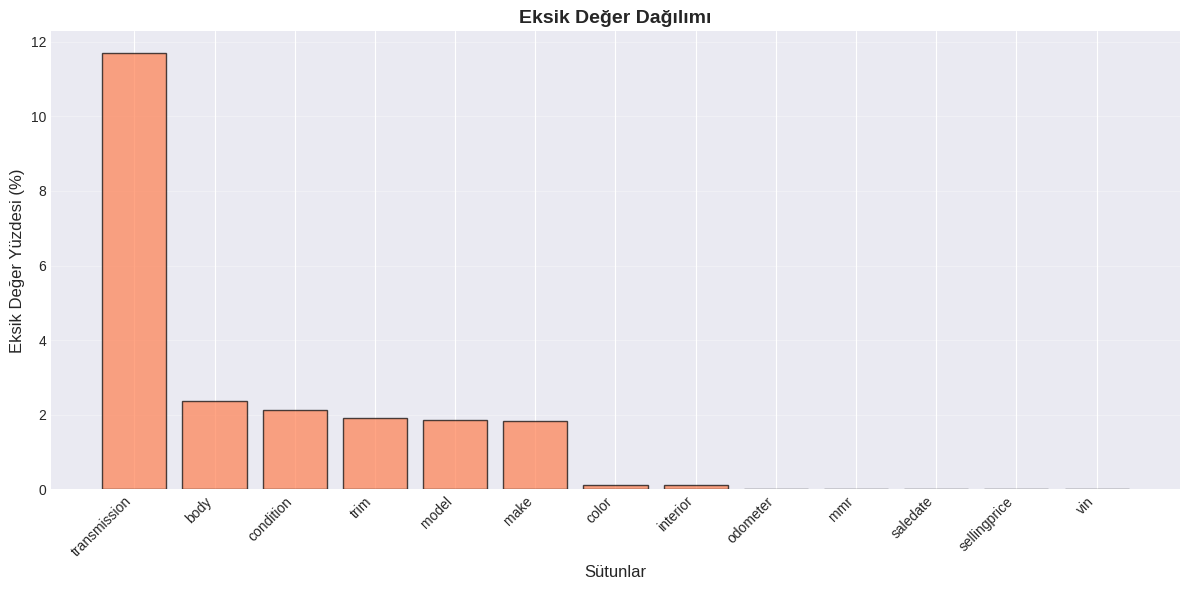


📊 Toplam Eksik Değer: 123,376
📊 Toplam Eksik Oran: 1.38%

📋 TÜM SÜTUNLAR - ÖZET
       Sütun  Eksik_Sayısı  Eksik_Yüzdesi Veri_Tipi  Unique_Değer
transmission         65352          11.69    object             4
        body         13195           2.36    object            87
   condition         11820           2.12   float64            41
        trim         10651           1.91    object          1963
       model         10399           1.86    object           973
        make         10301           1.84    object            96
       color           749           0.13    object            46
    interior           749           0.13    object            17
    odometer            94           0.02   float64        172278
         mmr            38           0.01   float64          1101
    saledate            12           0.00    object          3766
sellingprice            12           0.00   float64          1887
         vin             4           0.00    object        55

In [9]:
print("="*80)
print("🔍 EKSİK DEĞER ANALİZİ")
print("="*80)

# Eksik değer istatistikleri
missing_stats = pd.DataFrame({
    'Sütun': df.columns,
    'Eksik_Sayısı': df.isnull().sum(),
    'Eksik_Yüzdesi': (df.isnull().sum() / len(df) * 100).round(2),
    'Veri_Tipi': df.dtypes,
    'Unique_Değer': [df[col].nunique() for col in df.columns]
}).sort_values('Eksik_Sayısı', ascending=False)

# Sadece eksik değeri olanları göster
missing_stats_filtered = missing_stats[missing_stats['Eksik_Sayısı'] > 0]

if len(missing_stats_filtered) > 0:
    print("\n⚠️ Eksik Değer İçeren Sütunlar:")
    print("-" * 80)
    print(missing_stats_filtered.to_string(index=False))

    # Görselleştirme
    plt.figure(figsize=(12, 6))
    plt.bar(missing_stats_filtered['Sütun'], missing_stats_filtered['Eksik_Yüzdesi'],
            color='coral', edgecolor='black', alpha=0.7)
    plt.xlabel('Sütunlar', fontsize=12)
    plt.ylabel('Eksik Değer Yüzdesi (%)', fontsize=12)
    plt.title('Eksik Değer Dağılımı', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    print(f"\n📊 Toplam Eksik Değer: {df.isnull().sum().sum():,}")
    print(f"📊 Toplam Eksik Oran: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")
else:
    print("\n✅ Hiçbir sütunda eksik değer yok!")

# Tüm sütunlar için özet
print("\n" + "="*80)
print("📋 TÜM SÜTUNLAR - ÖZET")
print("="*80)
print(missing_stats.to_string(index=False))

## 🔢 5. DUPLICATE ANALİZİ

In [10]:
print("="*80)
print("🔍 DUPLICATE (TEKRAR EDEN) SATIR ANALİZİ")
print("="*80)

# Tam duplicate satırlar
duplicates = df.duplicated().sum()
print(f"\n📌 Tam Duplicate Satır Sayısı: {duplicates:,}")
print(f"📌 Duplicate Yüzdesi: {(duplicates/len(df)*100):.2f}%")

if duplicates > 0:
    print(f"\n⚠️ {duplicates:,} adet duplicate satır tespit edildi!")
    print("\nİlk 10 Duplicate Satır:")
    print("-" * 80)
    duplicate_rows = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
    print(duplicate_rows.head(10))
else:
    print("\n✅ Hiç duplicate satır yok!")

# Belirli sütunlara göre duplicate kontrolü
if len(df.columns) > 2:
    key_columns = df.columns[:3].tolist()  # İlk 3 sütun
    partial_duplicates = df.duplicated(subset=key_columns).sum()
    print(f"\n📌 {key_columns} sütunlarına göre duplicate: {partial_duplicates:,}")

🔍 DUPLICATE (TEKRAR EDEN) SATIR ANALİZİ

📌 Tam Duplicate Satır Sayısı: 0
📌 Duplicate Yüzdesi: 0.00%

✅ Hiç duplicate satır yok!

📌 ['year', 'make', 'model'] sütunlarına göre duplicate: 553,224


## 📊 6. TANIMLAYICI İSTATİSTİKLER (DESCRIPTIVE STATISTICS)

In [11]:
print("="*80)
print("📊 SAYISAL DEĞİŞKENLER - DETAYLI İSTATİSTİKLER")
print("="*80)

# Sayısal sütunları seç
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 0:
    # Temel istatistikler
    stats_df = df[numeric_cols].describe().T

    # Ek istatistikler
    stats_df['variance'] = df[numeric_cols].var()
    stats_df['skewness'] = df[numeric_cols].skew()
    stats_df['kurtosis'] = df[numeric_cols].kurtosis()
    stats_df['range'] = df[numeric_cols].max() - df[numeric_cols].min()
    stats_df['iqr'] = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
    stats_df['cv'] = (df[numeric_cols].std() / df[numeric_cols].mean() * 100).round(2)  # Coefficient of Variation

    print("\n" + stats_df.to_string())

    # Çarpıklık ve basıklık yorumu
    print("\n" + "="*80)
    print("📈 DAĞILIM ANALİZİ (Skewness & Kurtosis)")
    print("="*80)

    for col in numeric_cols:
        skew = df[col].skew()
        kurt = df[col].kurtosis()

        if abs(skew) < 0.5:
            skew_interpretation = "Simetrik"
        elif skew > 0:
            skew_interpretation = "Sağa Çarpık (Pozitif)"
        else:
            skew_interpretation = "Sola Çarpık (Negatif)"

        if abs(kurt) < 3:
            kurt_interpretation = "Normal (Mesokurtic)"
        elif kurt > 3:
            kurt_interpretation = "Sivri Uçlu (Leptokurtic)"
        else:
            kurt_interpretation = "Düz Uçlu (Platykurtic)"

        print(f"\n{col}:")
        print(f"  Skewness: {skew:.4f} ({skew_interpretation})")
        print(f"  Kurtosis: {kurt:.4f} ({kurt_interpretation})")
else:
    print("\n⚠️ Sayısal sütun bulunamadı!")

📊 SAYISAL DEĞİŞKENLER - DETAYLI İSTATİSTİKLER

                 count     mean      std     min      25%      50%      75%       max      variance  skewness  kurtosis     range      iqr    cv
year         558837.00  2010.04     3.97 1982.00  2007.00  2012.00  2013.00   2015.00         15.74     -1.18      1.01     33.00     6.00  0.20
condition    547017.00    30.67    13.40    1.00    23.00    35.00    42.00     49.00        179.64     -0.83     -0.22     48.00    19.00 43.70
odometer     558743.00 68320.02 53398.54    1.00 28371.00 52254.00 99109.00 999999.00 2851404375.36      1.84     13.55 999998.00 70738.00 78.16
mmr          558799.00 13769.38  9679.97   25.00  7100.00 12250.00 18300.00 182000.00   93701764.48      2.00     11.44 181975.00 11200.00 70.30
sellingprice 558825.00 13611.36  9749.50    1.00  6900.00 12100.00 18200.00 230000.00   95052781.99      1.95     11.11 229999.00 11300.00 71.63

📈 DAĞILIM ANALİZİ (Skewness & Kurtosis)

year:
  Skewness: -1.1832 (Sola Çarpık (N

📊 KATEGORİK DEĞİŞKENLER - DETAYLI İSTATİSTİKLER

📊 MAKE
        Değer  Sayı  Yüzde  Kümülatif
         Ford 93554  17.06      17.06
    Chevrolet 60197  10.97      28.03
       Nissan 53946   9.83      37.86
       Toyota 39871   7.27      45.13
        Dodge 30710   5.60      50.73
        Honda 27206   4.96      55.69
      Hyundai 21816   3.98      59.67
          BMW 20719   3.78      63.45
          Kia 18077   3.30      66.74
     Chrysler 17276   3.15      69.89
Mercedes-Benz 17141   3.12      73.01
         Jeep 15372   2.80      75.82
     Infiniti 15305   2.79      78.61
   Volkswagen 12581   2.29      80.90
        Lexus 11861   2.16      83.06
          GMC 10613   1.93      85.00
        Mazda  8362   1.52      86.52
     Cadillac  7519   1.37      87.89
        Acura  5901   1.08      88.97
         Audi  5869   1.07      90.04

📌 Unique Değer Sayısı: 96
📌 Mode (En Sık): Ford (93554 kez)
📌 Missing Values: 10301


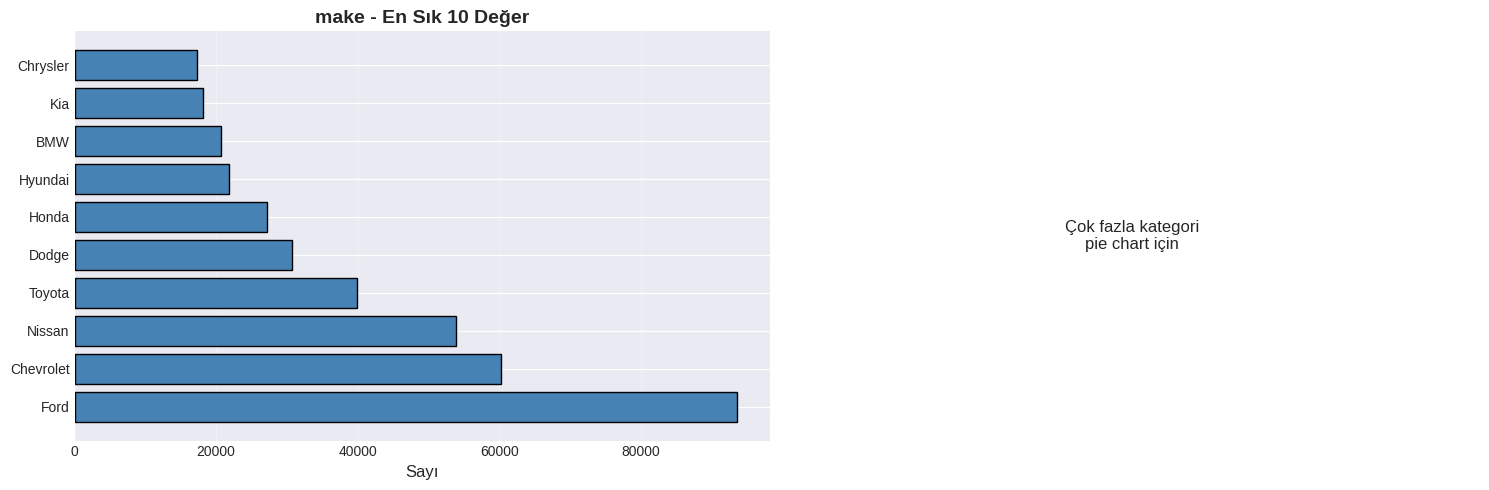


📊 MODEL
         Değer  Sayı  Yüzde  Kümülatif
        Altima 19349   3.53       3.53
         F-150 14479   2.64       6.17
        Fusion 12946   2.36       8.53
         Camry 12545   2.29      10.82
        Escape 11861   2.16      12.98
         Focus 10394   1.90      14.87
        Accord  9127   1.66      16.54
      3 Series  8204   1.50      18.03
 Grand Caravan  7941   1.45      19.48
        Impala  7923   1.44      20.93
      Explorer  7707   1.41      22.33
         Civic  7433   1.36      23.69
       G Sedan  7417   1.35      25.04
       Corolla  7354   1.34      26.38
        Malibu  7028   1.28      27.66
        Sonata  6914   1.26      28.92
        Maxima  6611   1.21      30.13
Silverado 1500  6362   1.16      31.29
         Cruze  6348   1.16      32.45
       Elantra  6262   1.14      33.59

📌 Unique Değer Sayısı: 973
📌 Mode (En Sık): Altima (19349 kez)
📌 Missing Values: 10399


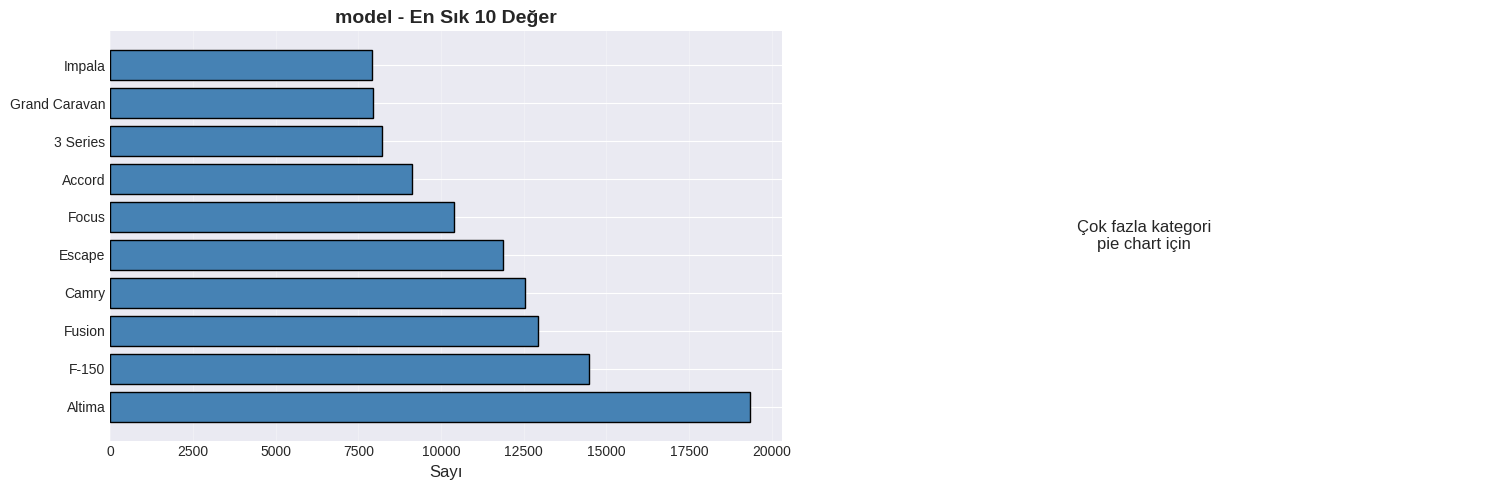


📊 TRIM
  Değer  Sayı  Yüzde  Kümülatif
   Base 55817  10.18      10.18
     SE 43648   7.96      18.14
     LX 20757   3.79      21.93
Limited 18367   3.35      25.28
     LT 16915   3.09      28.37
    XLT 16741   3.05      31.42
     LS 13427   2.45      33.87
     LE 12903   2.35      36.22
    GLS 12331   2.25      38.47
      S 11883   2.17      40.64
  2.5 S 11212   2.05      42.69
    SXT 11196   2.04      44.73
Touring 11111   2.03      46.76
    SEL 10479   1.91      48.67
     EX  9472   1.73      50.40
  Sport  9076   1.66      52.05
    2.5  6908   1.26      53.31
    SLT  6013   1.10      54.41
     SV  5700   1.04      55.45
   EX-L  5382   0.98      56.43

📌 Unique Değer Sayısı: 1963
📌 Mode (En Sık): Base (55817 kez)
📌 Missing Values: 10651


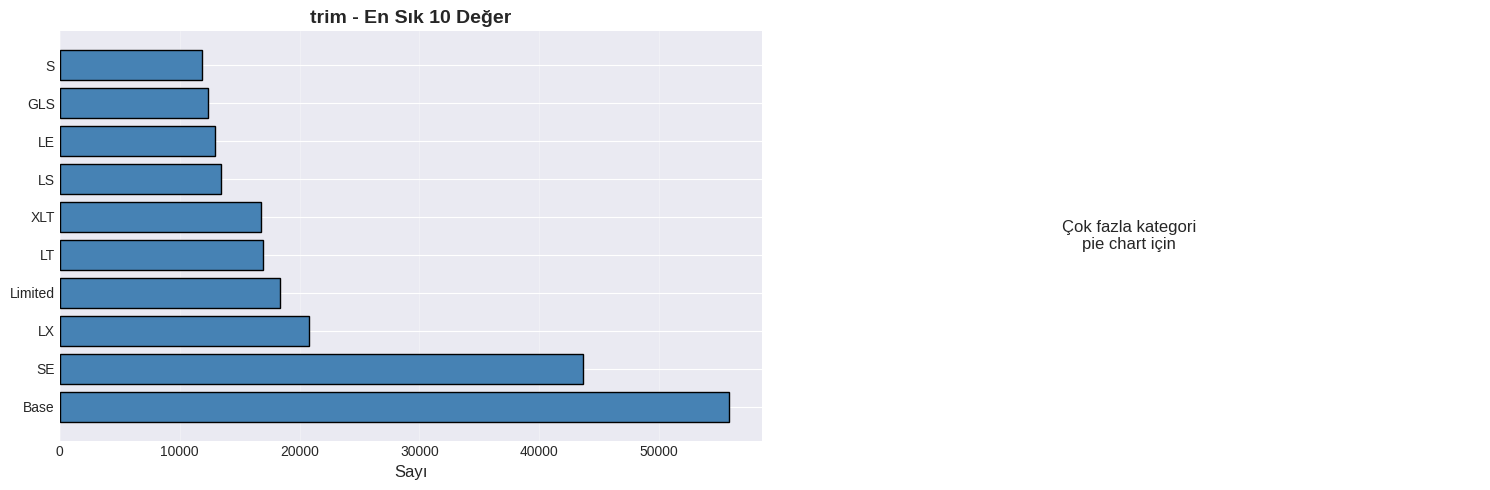


📊 BODY
       Değer   Sayı  Yüzde  Kümülatif
       Sedan 199437  36.55      36.55
         SUV 119292  21.86      58.41
       sedan  41906   7.68      66.09
         suv  24552   4.50      70.59
   Hatchback  21380   3.92      74.51
     Minivan  21363   3.92      78.43
       Coupe  14602   2.68      81.10
       Wagon  13630   2.50      83.60
    Crew Cab  13280   2.43      86.03
 Convertible   8652   1.59      87.62
   SuperCrew   7423   1.36      88.98
     G Sedan   5999   1.10      90.08
   hatchback   4857   0.89      90.97
    SuperCab   4449   0.82      91.79
     minivan   4166   0.76      92.55
 Regular Cab   4067   0.75      93.29
         Van   3958   0.73      94.02
Extended Cab   3824   0.70      94.72
    Quad Cab   3436   0.63      95.35
       coupe   3150   0.58      95.93

📌 Unique Değer Sayısı: 87
📌 Mode (En Sık): Sedan (199437 kez)
📌 Missing Values: 13195


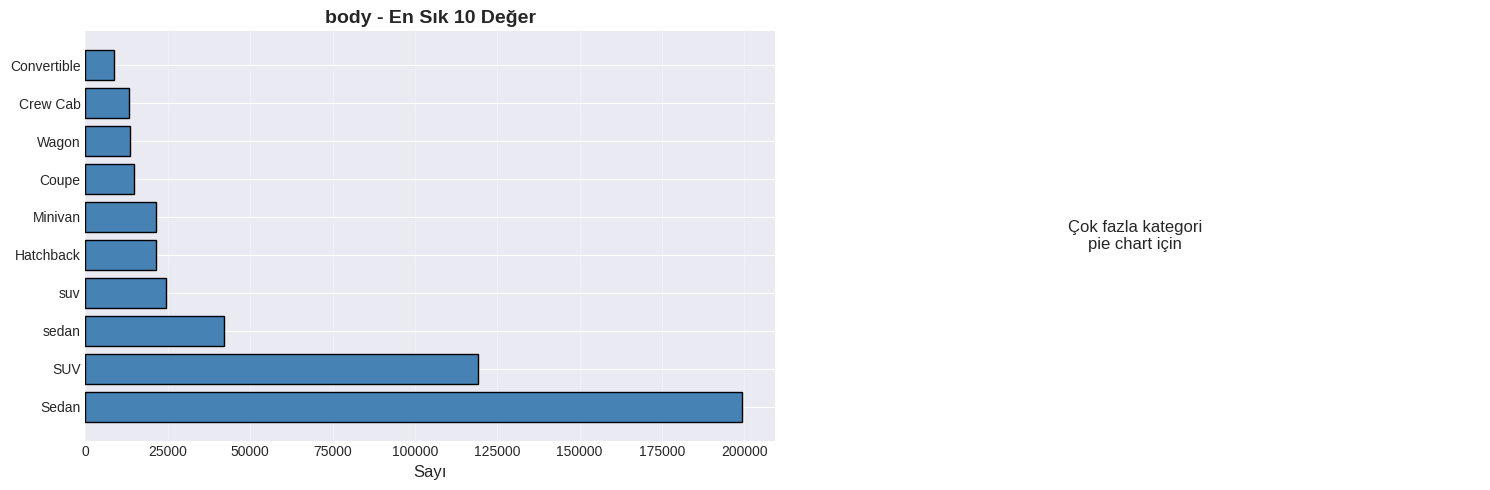


📊 TRANSMISSION
    Değer   Sayı  Yüzde  Kümülatif
automatic 475915  96.44      96.44
   manual  17544   3.56      99.99
    sedan     15   0.00     100.00
    Sedan     11   0.00     100.00

📌 Unique Değer Sayısı: 4
📌 Mode (En Sık): automatic (475915 kez)
📌 Missing Values: 65352


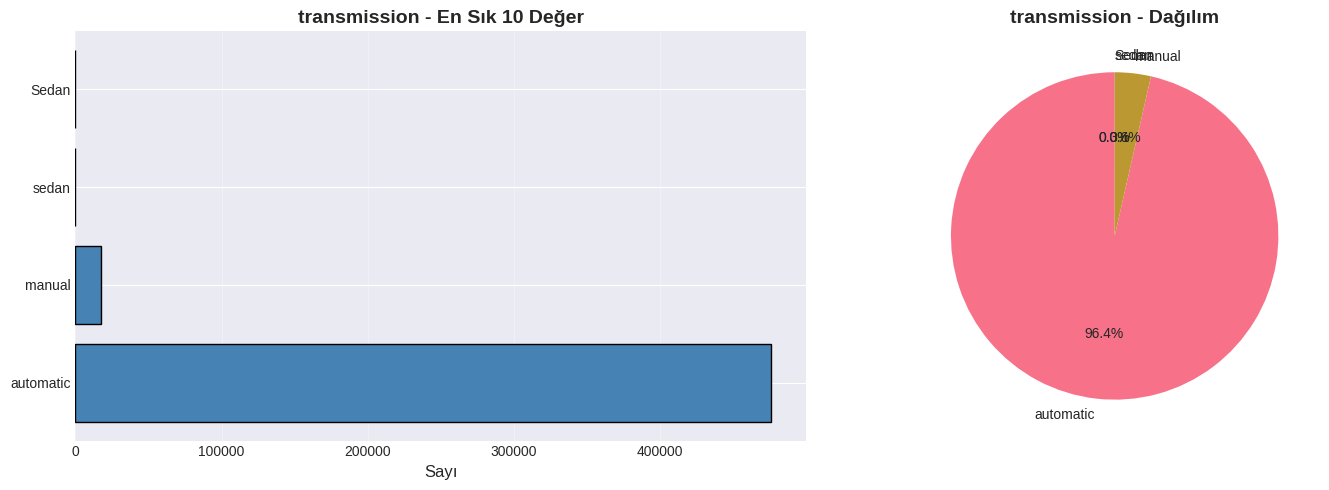


📊 VIN
            Değer  Sayı  Yüzde  Kümülatif
        automatic    22   0.00       0.00
wbanv13588cz57827     5   0.00       0.00
wddgf56x78f009940     4   0.00       0.01
1ftfw1cv5afb30053     4   0.00       0.01
5uxfe43579l274932     4   0.00       0.01
trusc28n241022003     4   0.00       0.01
5n1ar1nn2bc632869     4   0.00       0.01
wp0ca2988xu629622     4   0.00       0.01
5uxfe43558l025558     3   0.00       0.01
5tdzt34a13s196471     3   0.00       0.01
2gnalbek0d6315905     3   0.00       0.01
1zvbp8am7d5254220     3   0.00       0.01
wdbrf61j94f511899     3   0.00       0.01
1gyfk63887r125174     3   0.00       0.01
2hnyd2h67ah527455     3   0.00       0.01
3gnec12z46g106364     3   0.00       0.01
wp0ab2a75cl062020     3   0.00       0.01
5uxfe43577l019100     3   0.00       0.01
4t1be46k17u593036     3   0.00       0.02
3g5da03e02s544314     3   0.00       0.02

📌 Unique Değer Sayısı: 550297
📌 Mode (En Sık): automatic (22 kez)
📌 Missing Values: 4


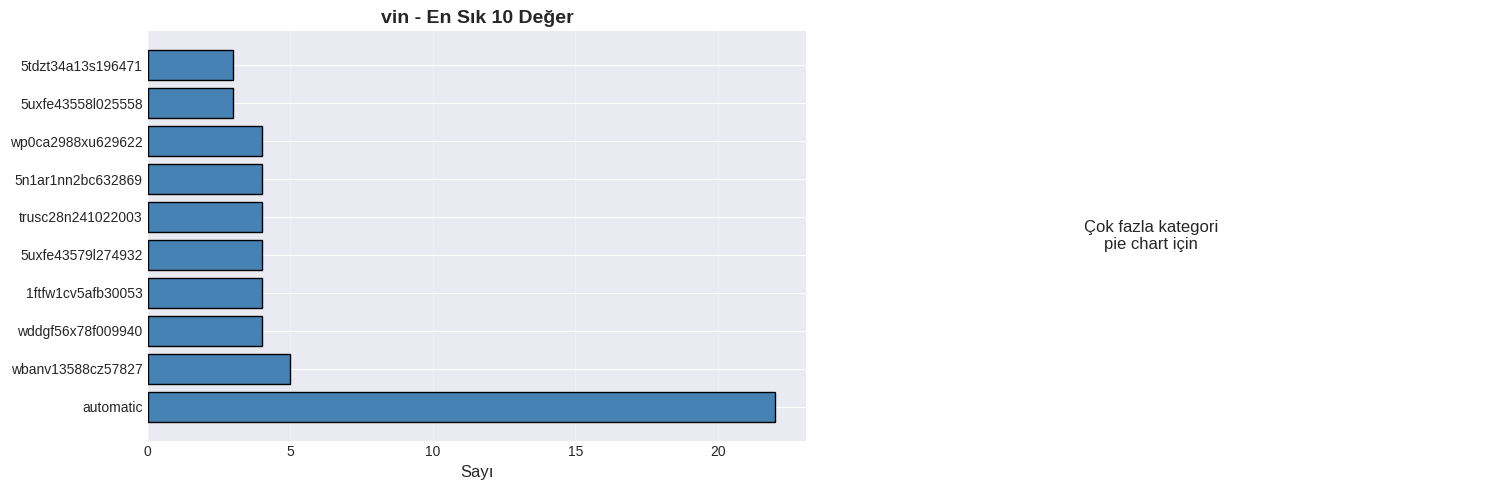


📊 STATE
Değer  Sayı  Yüzde  Kümülatif
   fl 82945  14.84      14.84
   ca 73148  13.09      27.93
   pa 53907   9.65      37.58
   tx 45913   8.22      45.79
   ga 34750   6.22      52.01
   nj 27784   4.97      56.98
   il 23486   4.20      61.19
   nc 21845   3.91      65.10
   oh 21575   3.86      68.96
   tn 20895   3.74      72.70
   mo 16013   2.87      75.56
   mi 15511   2.78      78.34
   nv 12685   2.27      80.61
   va 12027   2.15      82.76
   md 11158   2.00      84.75
   wi  9851   1.76      86.52
   mn  9429   1.69      88.20
   az  8741   1.56      89.77
   co  7775   1.39      91.16
   wa  7416   1.33      92.49

📌 Unique Değer Sayısı: 64
📌 Mode (En Sık): fl (82945 kez)
📌 Missing Values: 0


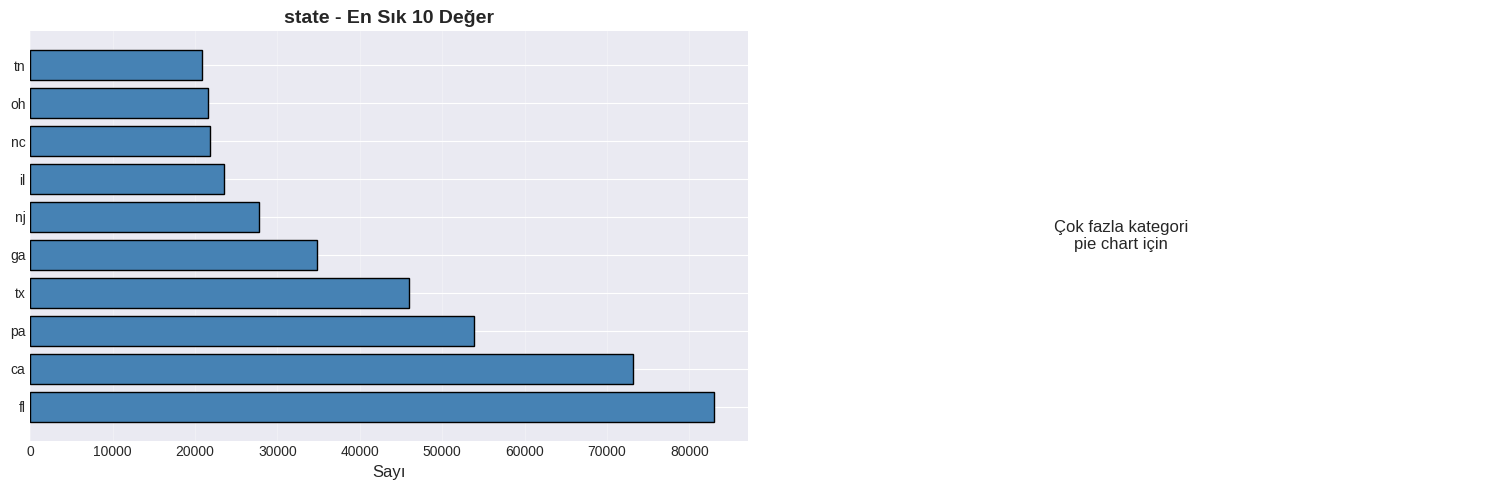


📊 COLOR
    Değer   Sayı  Yüzde  Kümülatif
    black 110970  19.88      19.88
    white 106673  19.11      39.00
   silver  83389  14.94      53.94
     gray  82857  14.85      68.79
     blue  51139   9.16      77.95
      red  43569   7.81      85.76
        —  24685   4.42      90.18
    green  11382   2.04      92.22
     gold  11342   2.03      94.25
    beige   9222   1.65      95.90
 burgundy   8972   1.61      97.51
    brown   6717   1.20      98.72
   orange   2078   0.37      99.09
   purple   1561   0.28      99.37
off-white   1449   0.26      99.63
   yellow   1285   0.23      99.86
 charcoal    479   0.09      99.94
turquoise    236   0.04      99.99
     pink     42   0.01      99.99
     lime     15   0.00     100.00

📌 Unique Değer Sayısı: 46
📌 Mode (En Sık): black (110970 kez)
📌 Missing Values: 749


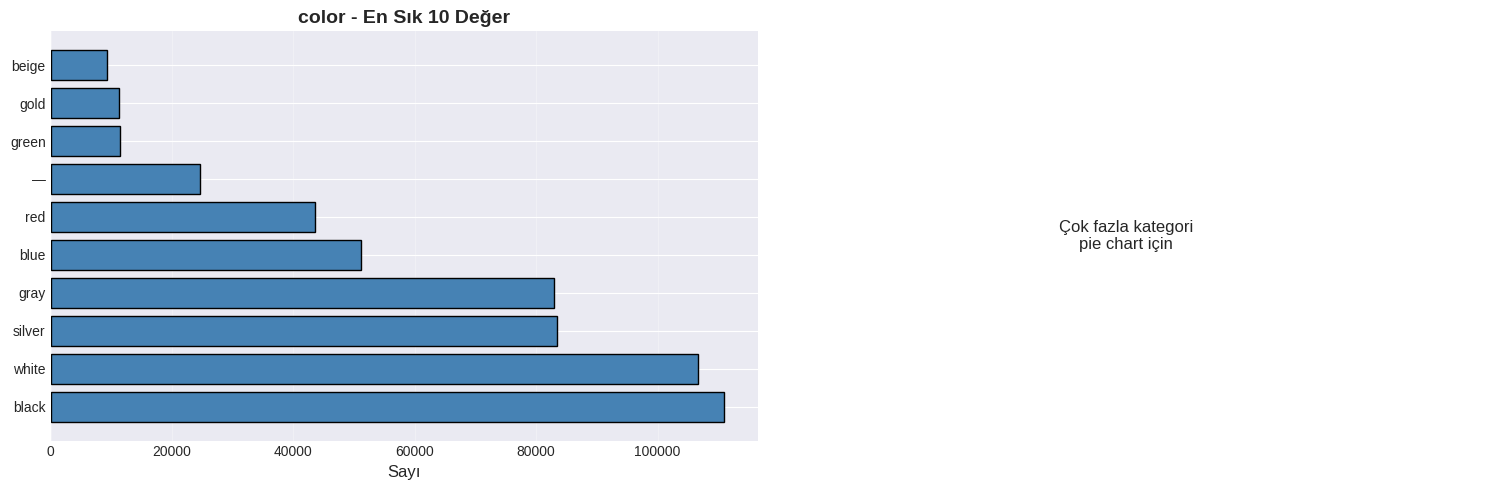


📊 INTERIOR
    Değer   Sayı  Yüzde  Kümülatif
    black 244329  43.78      43.78
     gray 178581  32.00      75.78
    beige  59758  10.71      86.49
      tan  44093   7.90      94.39
        —  17077   3.06      97.45
    brown   8640   1.55      98.99
      red   1363   0.24      99.24
     blue   1143   0.20      99.44
   silver   1104   0.20      99.64
off-white    480   0.09      99.73
   purple    339   0.06      99.79
     gold    324   0.06      99.85
    white    256   0.05      99.89
    green    245   0.04      99.94
 burgundy    191   0.03      99.97
   orange    145   0.03     100.00
   yellow     20   0.00     100.00

📌 Unique Değer Sayısı: 17
📌 Mode (En Sık): black (244329 kez)
📌 Missing Values: 749


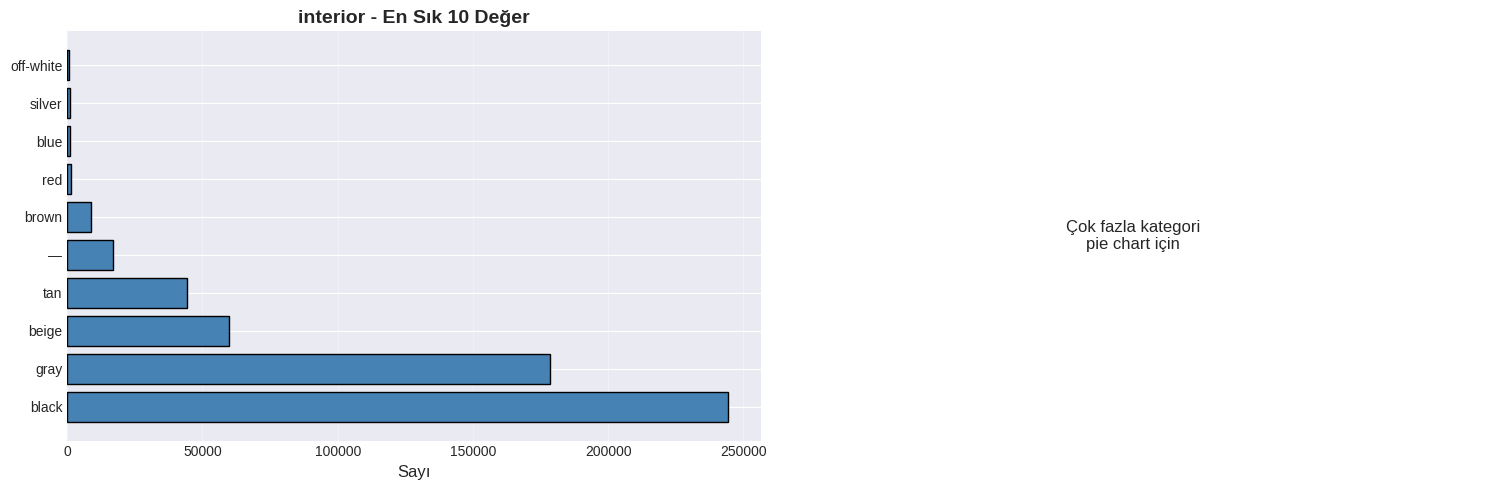


📊 SELLER
                                 Değer  Sayı  Yüzde  Kümülatif
                    nissan-infiniti lt 19693   3.52       3.52
         ford motor credit company llc 19162   3.43       6.95
                 the hertz corporation 18299   3.27      10.23
                    santander consumer 15285   2.74      12.96
                      avis corporation 12540   2.24      15.21
                    nissan infiniti lt  9962   1.78      16.99
           wells fargo dealer services  8796   1.57      18.56
                      tdaf remarketing  7209   1.29      19.85
        enterprise veh exchange/rental  6853   1.23      21.08
 ge fleet services for itself/servicer  6692   1.20      22.28
                 hyundai motor finance  6660   1.19      23.47
              jpmorgan chase bank n.a.  6235   1.12      24.58
  ahfc/honda lease trust/hvt  inc. eot  6069   1.09      25.67
financial services remarketing (lease)  6009   1.08      26.75
      mercedes-benz financial services  5658 

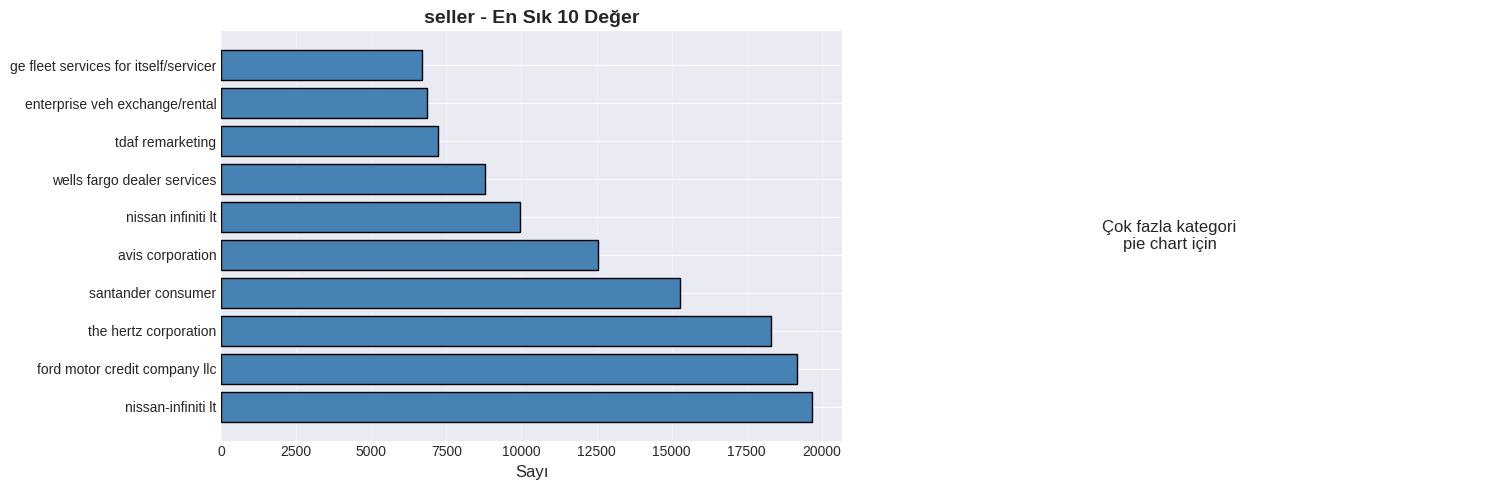


📊 SALEDATE
                                  Değer  Sayı  Yüzde  Kümülatif
Tue Feb 10 2015 01:30:00 GMT-0800 (PST)  5334   0.95       0.95
Tue Feb 17 2015 01:30:00 GMT-0800 (PST)  5016   0.90       1.85
Tue Jan 27 2015 01:30:00 GMT-0800 (PST)  4902   0.88       2.73
Tue Jan 20 2015 01:30:00 GMT-0800 (PST)  4731   0.85       3.58
Tue Mar 03 2015 01:30:00 GMT-0800 (PST)  4653   0.83       4.41
Tue Feb 03 2015 01:30:00 GMT-0800 (PST)  4593   0.82       5.23
Tue Jun 02 2015 02:30:00 GMT-0700 (PDT)  4368   0.78       6.01
Tue Jun 16 2015 02:30:00 GMT-0700 (PDT)  4204   0.75       6.76
Tue Mar 10 2015 02:30:00 GMT-0700 (PDT)  4019   0.72       7.48
Thu Dec 18 2014 10:00:00 GMT-0800 (PST)  3601   0.64       8.13
Tue Feb 24 2015 01:30:00 GMT-0800 (PST)  3596   0.64       8.77
Wed Jan 28 2015 02:00:00 GMT-0800 (PST)  3449   0.62       9.39
Tue May 26 2015 02:30:00 GMT-0700 (PDT)  3260   0.58       9.97
Wed Feb 11 2015 01:30:00 GMT-0800 (PST)  3201   0.57      10.54
Tue Jan 13 2015 09:30:00 GMT

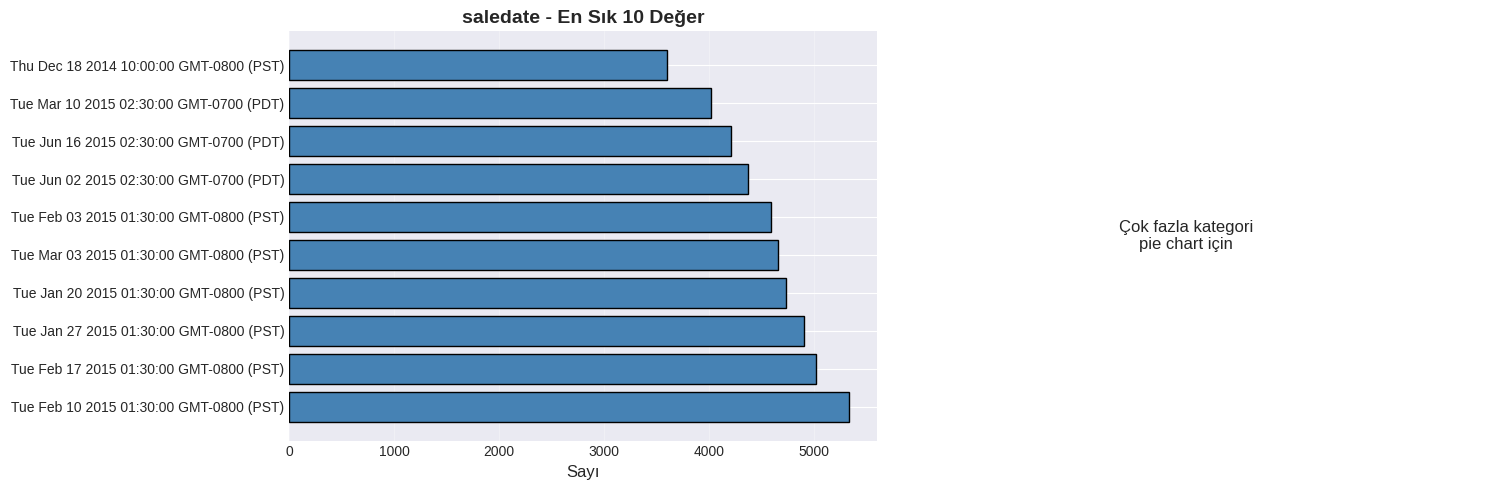

In [12]:
print("="*80)
print("📊 KATEGORİK DEĞİŞKENLER - DETAYLI İSTATİSTİKLER")
print("="*80)

# Kategorik sütunları seç
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 0:
    for col in categorical_cols:
        print(f"\n{'='*80}")
        print(f"📊 {col.upper()}")
        print(f"{'='*80}")

        value_counts = df[col].value_counts()
        percentages = df[col].value_counts(normalize=True) * 100
        cumulative = percentages.cumsum()

        result = pd.DataFrame({
            'Değer': value_counts.index,
            'Sayı': value_counts.values,
            'Yüzde': percentages.values.round(2),
            'Kümülatif': cumulative.values.round(2)
        })

        # İlk 20 değeri göster
        print(result.head(20).to_string(index=False))

        print(f"\n📌 Unique Değer Sayısı: {df[col].nunique()}")
        print(f"📌 Mode (En Sık): {df[col].mode()[0] if not df[col].mode().empty else 'N/A'} ({value_counts.iloc[0]} kez)")
        print(f"📌 Missing Values: {df[col].isnull().sum()}")

        # Görselleştirme (top 10)
        if df[col].nunique() > 1:
            top_10 = value_counts.head(10)

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

            # Bar plot
            ax1.barh(range(len(top_10)), top_10.values, color='steelblue', edgecolor='black')
            ax1.set_yticks(range(len(top_10)))
            ax1.set_yticklabels(top_10.index)
            ax1.set_xlabel('Sayı', fontsize=12)
            ax1.set_title(f'{col} - En Sık 10 Değer', fontsize=14, fontweight='bold')
            ax1.grid(True, alpha=0.3, axis='x')

            # Pie chart
            if len(top_10) <= 8:
                ax2.pie(top_10.values, labels=top_10.index, autopct='%1.1f%%', startangle=90)
                ax2.set_title(f'{col} - Dağılım', fontsize=14, fontweight='bold')
            else:
                ax2.axis('off')
                ax2.text(0.5, 0.5, 'Çok fazla kategori\npie chart için',
                        ha='center', va='center', fontsize=12)

            plt.tight_layout()
            plt.show()
else:
    print("\n⚠️ Kategorik sütun bulunamadı!")

## 📈 7. OUTLIER (AYKIRI DEĞER) ANALİZİ

🔍 OUTLIER (AYKIRI DEĞER) ANALİZİ

       Sütun       Q1       Q3      IQR  Alt_Sınır  Üst_Sınır  Outlier_Sayısı  Outlier_Yüzdesi
        year  2007.00  2013.00     6.00    1998.00    2022.00            4021             0.72
   condition    23.00    42.00    19.00      -5.50      70.50               0             0.00
    odometer 28371.00 99109.00 70738.00  -77736.00  205216.00           10375             1.86
         mmr  7100.00 18300.00 11200.00   -9700.00   35100.00           16315             2.92
sellingprice  6900.00 18200.00 11300.00  -10050.00   35150.00           16354             2.93


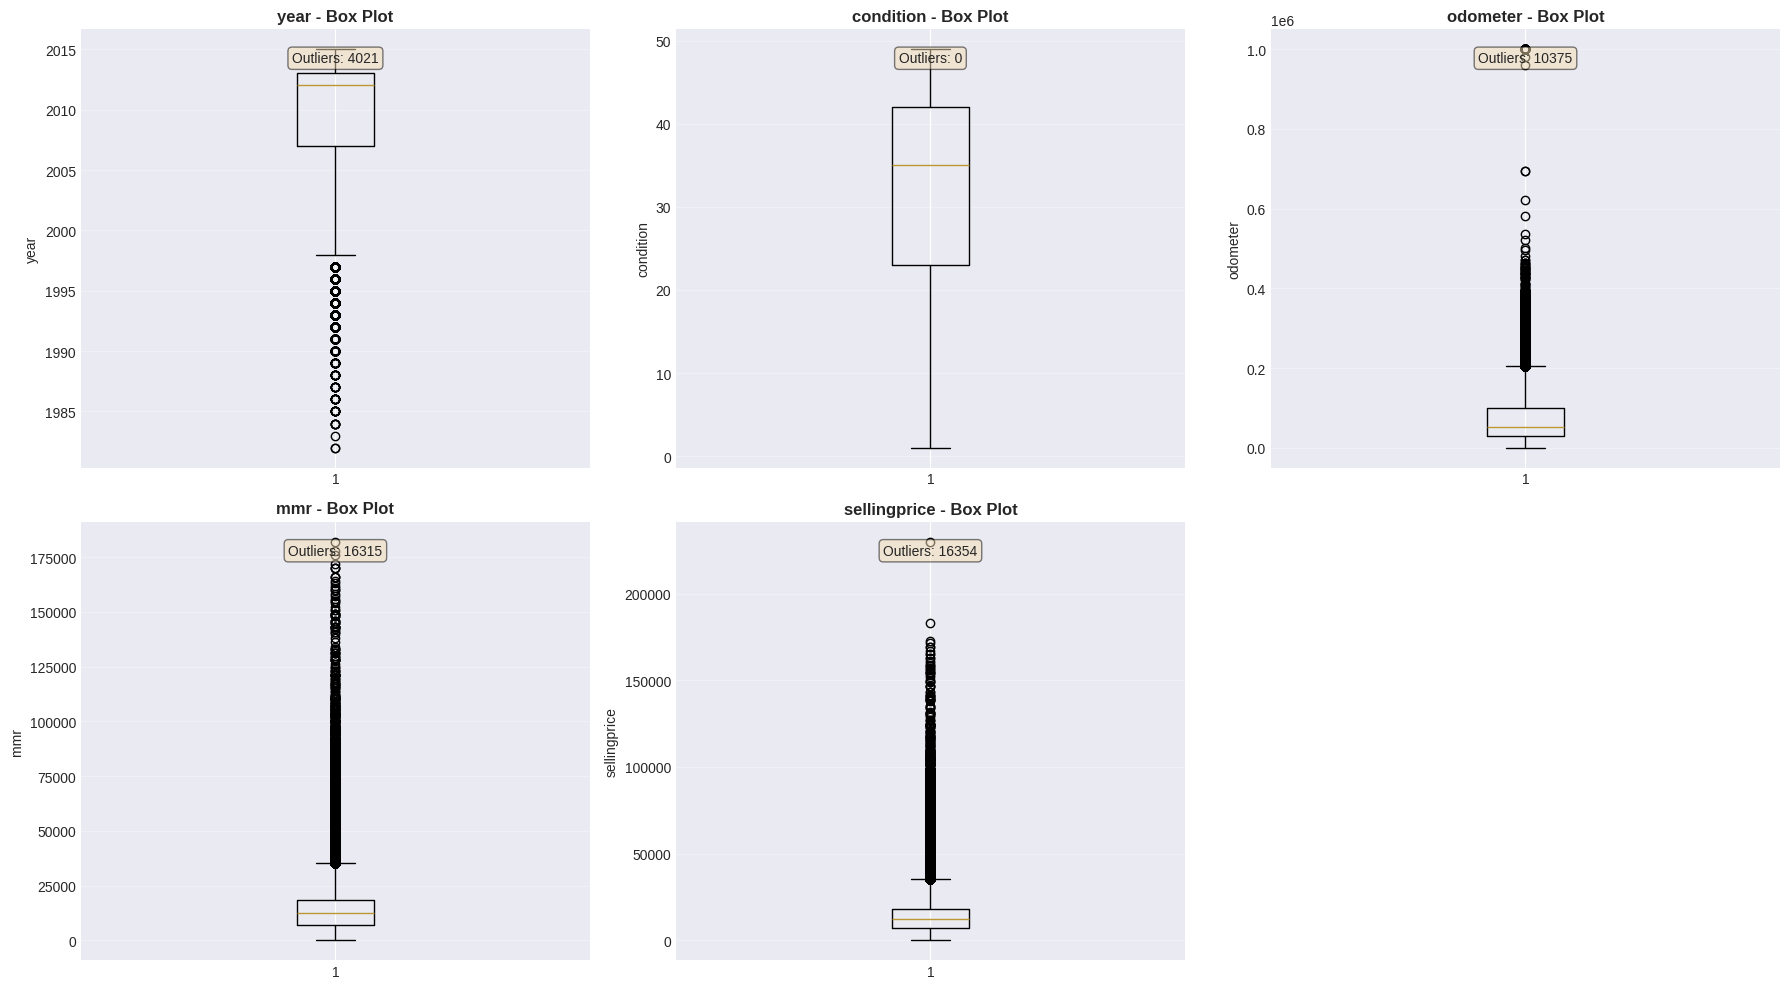

In [13]:
print("="*80)
print("🔍 OUTLIER (AYKIRI DEĞER) ANALİZİ")
print("="*80)

if len(numeric_cols) > 0:
    outlier_summary = []

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(df)) * 100

        outlier_summary.append({
            'Sütun': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Alt_Sınır': lower_bound,
            'Üst_Sınır': upper_bound,
            'Outlier_Sayısı': outlier_count,
            'Outlier_Yüzdesi': round(outlier_percentage, 2)
        })

    outlier_df = pd.DataFrame(outlier_summary)
    print("\n" + outlier_df.to_string(index=False))

    # Box plot visualizations
    n_cols = len(numeric_cols)
    n_rows = (n_cols + 2) // 3

    fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows * 5))
    axes = axes.flatten() if n_cols > 1 else [axes]

    for idx, col in enumerate(numeric_cols):
        axes[idx].boxplot(df[col].dropna(), vert=True)
        axes[idx].set_title(f'{col} - Box Plot', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(col, fontsize=10)
        axes[idx].grid(True, alpha=0.3, axis='y')

        # Outlier sayısını ekle
        outlier_count = outlier_df[outlier_df['Sütun'] == col]['Outlier_Sayısı'].values[0]
        axes[idx].text(0.5, 0.95, f'Outliers: {outlier_count}',
                      transform=axes[idx].transAxes,
                      ha='center', va='top', fontsize=10,
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Boş subplot'ları gizle
    for idx in range(n_cols, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Sayısal sütun bulunamadı!")

## 🧹 8. VERİ TEMİZLEME VE ÖNİŞLEME

In [14]:
print("="*80)
print("🧹 VERİ TEMİZLEME VE ÖNİŞLEME")
print("="*80)

# Orijinal veri boyutu
original_shape = df.shape
print(f"\n📌 Orijinal Boyut: {original_shape[0]:,} satır x {original_shape[1]} sütun")

# 1. Duplicate satırları kaldır
if df.duplicated().sum() > 0:
    before_dup = len(df)
    df = df.drop_duplicates()
    after_dup = len(df)
    print(f"\n✅ {before_dup - after_dup:,} duplicate satır kaldırıldı")
else:
    print("\n✅ Duplicate satır yok")

# 2. Tarih sütunlarını datetime'a çevir
date_columns = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
if date_columns:
    for col in date_columns:
        try:
            df[col] = pd.to_datetime(df[col], errors='coerce')
            print(f"✅ {col} datetime'a çevrildi")
        except:
            print(f"⚠️ {col} datetime'a çevrilemedi")

# 3. Sayısal sütunların veri tiplerini optimize et
for col in numeric_cols:
    if df[col].dtype == 'float64':
        if df[col].isnull().sum() == 0 and (df[col] % 1 == 0).all():
            df[col] = df[col].astype('int64')
            print(f"✅ {col} int64'e çevrildi")

# 4. Eksik değerleri doldur (stratejik yaklaşım)
print("\n📊 Eksik Değer Doldurma Stratejisi:")
print("-" * 80)

for col in df.columns:
    missing_count = df[col].isnull().sum()

    if missing_count > 0:
        missing_percentage = (missing_count / len(df)) * 100

        # Eğer %50'den fazla eksik ise sütunu kaldır
        if missing_percentage > 50:
            df = df.drop(columns=[col])
            print(f"  ❌ {col}: %{missing_percentage:.2f} eksik, sütun kaldırıldı")

        # Sayısal sütunlar için median
        elif df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"  ✅ {col}: {missing_count} eksik değer median ile dolduruldu")

        # Kategorik sütunlar için mode
        elif df[col].dtype == 'object':
            if not df[col].mode().empty:
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f"  ✅ {col}: {missing_count} eksik değer mode ile dolduruldu")
            else:
                df[col].fillna('Unknown', inplace=True)
                print(f"  ✅ {col}: {missing_count} eksik değer 'Unknown' ile dolduruldu")

# 5. Final durum
final_shape = df.shape
print(f"\n📌 Temizlenmiş Boyut: {final_shape[0]:,} satır x {final_shape[1]} sütun")
print(f"📌 Kalan Eksik Değer: {df.isnull().sum().sum()}")
print(f"📌 Bellek Kullanımı: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "="*80)
print("✅ VERİ TEMİZLEME TAMAMLANDI!")
print("="*80)

🧹 VERİ TEMİZLEME VE ÖNİŞLEME

📌 Orijinal Boyut: 558,837 satır x 16 sütun

✅ Duplicate satır yok
✅ saledate datetime'a çevrildi

📊 Eksik Değer Doldurma Stratejisi:
--------------------------------------------------------------------------------
  ✅ make: 10301 eksik değer mode ile dolduruldu
  ✅ model: 10399 eksik değer mode ile dolduruldu
  ✅ trim: 10651 eksik değer mode ile dolduruldu
  ✅ body: 13195 eksik değer mode ile dolduruldu
  ✅ transmission: 65352 eksik değer mode ile dolduruldu
  ✅ vin: 4 eksik değer mode ile dolduruldu
  ✅ condition: 11820 eksik değer median ile dolduruldu
  ✅ odometer: 94 eksik değer median ile dolduruldu
  ✅ color: 749 eksik değer mode ile dolduruldu
  ✅ interior: 749 eksik değer mode ile dolduruldu
  ✅ mmr: 38 eksik değer median ile dolduruldu
  ✅ sellingprice: 12 eksik değer median ile dolduruldu
  ✅ saledate: 38 eksik değer mode ile dolduruldu

📌 Temizlenmiş Boyut: 558,837 satır x 16 sütun
📌 Kalan Eksik Değer: 0
📌 Bellek Kullanımı: 357.07 MB

✅ VERİ TEM

In [15]:
# Temizlenmiş verinin özeti
print("\n📊 TEMİZLENMİŞ VERİ ÖZETİ")
print("="*80)
df.info()


📊 TEMİZLENMİŞ VERİ ÖZETİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          558837 non-null  object 
 2   model         558837 non-null  object 
 3   trim          558837 non-null  object 
 4   body          558837 non-null  object 
 5   transmission  558837 non-null  object 
 6   vin           558837 non-null  object 
 7   state         558837 non-null  object 
 8   condition     558837 non-null  float64
 9   odometer      558837 non-null  float64
 10  color         558837 non-null  object 
 11  interior      558837 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558837 non-null  float64
 14  sellingprice  558837 non-null  float64
 15  saledate      558837 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


## 🔧 9. FEATURE ENGINEERING (GELİŞMİŞ ÖZELLİK ÇIKARIMI)

In [16]:
print("="*80)
print("🔧 ADVANCED FEATURE ENGINEERING")
print("="*80)

# Önceki sütun sayısı
before_features = df.shape[1]
print(f"\n📌 Başlangıç Sütun Sayısı: {before_features}")
print("\n🚀 Yeni özellikler oluşturuluyor...\n")

# DataFrame'in bir kopyasını al
df_original = df.copy()

# Feature Engineering'i dene
try:
    # Tarih bazlı özellikler (eğer tarih sütunu varsa)
    date_cols = df.select_dtypes(include=['datetime64']).columns

    if len(date_cols) > 0:
        for date_col in date_cols:
            df[f'{date_col}_year'] = df[date_col].dt.year
            df[f'{date_col}_month'] = df[date_col].dt.month
            df[f'{date_col}_day'] = df[date_col].dt.day
            df[f'{date_col}_quarter'] = df[date_col].dt.quarter
            df[f'{date_col}_dayofweek'] = df[date_col].dt.dayofweek
            df[f'{date_col}_is_weekend'] = (df[date_col].dt.dayofweek >= 5).astype(int)
            print(f"✅ {date_col} için 6 tarih özelliği oluşturuldu")

    # Sayısal özellikler arası etkileşimler
    numeric_cols_current = df.select_dtypes(include=[np.number]).columns.tolist()

    # İlk birkaç sayısal sütun için etkileşim özellikleri
    if len(numeric_cols_current) >= 2:
        # İlk 3 sayısal sütunu al
        key_numeric = numeric_cols_current[:min(3, len(numeric_cols_current))]

        for i in range(len(key_numeric)):
            for j in range(i+1, len(key_numeric)):
                col1, col2 = key_numeric[i], key_numeric[j]

                # Çarpım
                df[f'{col1}_x_{col2}'] = df[col1] * df[col2]

                # Bölüm (sıfıra bölmeyi önle)
                if (df[col2] != 0).all():
                    df[f'{col1}_div_{col2}'] = df[col1] / (df[col2] + 1e-6)

                print(f"✅ {col1} x {col2} etkileşim özellikleri oluşturuldu")

    # Logaritmik dönüşümler (pozitif değerler için)
    for col in numeric_cols_current[:min(5, len(numeric_cols_current))]:
        if (df[col] > 0).all():
            df[f'{col}_log'] = np.log1p(df[col])
            print(f"✅ {col}_log oluşturuldu")

    # Kare ve karekök dönüşümleri
    for col in numeric_cols_current[:min(3, len(numeric_cols_current))]:
        if (df[col] >= 0).all():
            df[f'{col}_squared'] = df[col] ** 2
            df[f'{col}_sqrt'] = np.sqrt(df[col])
            print(f"✅ {col}_squared ve {col}_sqrt oluşturuldu")

    # Kategorik değişkenler için frequency encoding
    categorical_cols_current = df.select_dtypes(include=['object']).columns.tolist()

    for col in categorical_cols_current[:min(3, len(categorical_cols_current))]:
        freq_encoding = df[col].value_counts(normalize=True).to_dict()
        df[f'{col}_frequency'] = df[col].map(freq_encoding)
        print(f"✅ {col}_frequency oluşturuldu")

    # Sonuç
    after_features = df.shape[1]
    new_features = after_features - before_features

    print(f"\n{'='*80}")
    print(f"🎉 Feature Engineering Tamamlandı!")
    print(f"{'='*80}")
    print(f"📌 Yeni Sütun Sayısı: {after_features}")
    print(f"📌 Eklenen Özellik: {new_features}")
    print(f"📌 Artış Oranı: %{(new_features/before_features*100):.1f}")

except Exception as e:
    print(f"\n⚠️ Feature Engineering sırasında hata: {e}")
    print("Orijinal DataFrame korundu.")
    df = df_original

🔧 ADVANCED FEATURE ENGINEERING

📌 Başlangıç Sütun Sayısı: 16

🚀 Yeni özellikler oluşturuluyor...

✅ year x condition etkileşim özellikleri oluşturuldu
✅ year x odometer etkileşim özellikleri oluşturuldu
✅ condition x odometer etkileşim özellikleri oluşturuldu
✅ year_log oluşturuldu
✅ condition_log oluşturuldu
✅ odometer_log oluşturuldu
✅ mmr_log oluşturuldu
✅ sellingprice_log oluşturuldu
✅ year_squared ve year_sqrt oluşturuldu
✅ condition_squared ve condition_sqrt oluşturuldu
✅ odometer_squared ve odometer_sqrt oluşturuldu
✅ make_frequency oluşturuldu
✅ model_frequency oluşturuldu
✅ trim_frequency oluşturuldu

🎉 Feature Engineering Tamamlandı!
📌 Yeni Sütun Sayısı: 36
📌 Eklenen Özellik: 20
📌 Artış Oranı: %125.0


In [17]:
# Yeni özelliklerin listesi
new_columns = [col for col in df.columns if col not in df_original.columns]

if new_columns:
    print("\n📋 OLUŞTURULAN YENİ ÖZELLİKLER:")
    print("="*80)
    for i, col in enumerate(new_columns, 1):
        print(f"{i:3d}. {col}")

    # İlk birkaç yeni özelliğin istatistikleri
    print("\n📊 Yeni Özelliklerin İstatistikleri (İlk 10):")
    print("="*80)
    if len(new_columns) > 0:
        numeric_new = [col for col in new_columns if df[col].dtype in ['int64', 'float64']]
        if numeric_new:
            print(df[numeric_new[:10]].describe().T)


📋 OLUŞTURULAN YENİ ÖZELLİKLER:
  1. year_x_condition
  2. year_div_condition
  3. year_x_odometer
  4. year_div_odometer
  5. condition_x_odometer
  6. condition_div_odometer
  7. year_log
  8. condition_log
  9. odometer_log
 10. mmr_log
 11. sellingprice_log
 12. year_squared
 13. year_sqrt
 14. condition_squared
 15. condition_sqrt
 16. odometer_squared
 17. odometer_sqrt
 18. make_frequency
 19. model_frequency
 20. trim_frequency

📊 Yeni Özelliklerin İstatistikleri (İlk 10):
                           count         mean          std     min  \
year_x_condition       558837.00     61853.67     26723.70 1984.00   
year_div_condition     558837.00       157.33       300.62   40.78   
year_x_odometer        558837.00 137156859.57 106952332.42 1990.00   
year_div_odometer      558837.00         4.94        97.52    0.00   
condition_x_odometer   558837.00   1885818.80   1476180.83    1.00   
condition_div_odometer 558837.00         0.03         0.90    0.00   
year_log               5

## 📊 10. EXPLORATORYdata ANALYSIS (EDA) - VİZUALİZASYONLAR

### 10.1 Univariate Analysis (Tek Değişken Analizi)

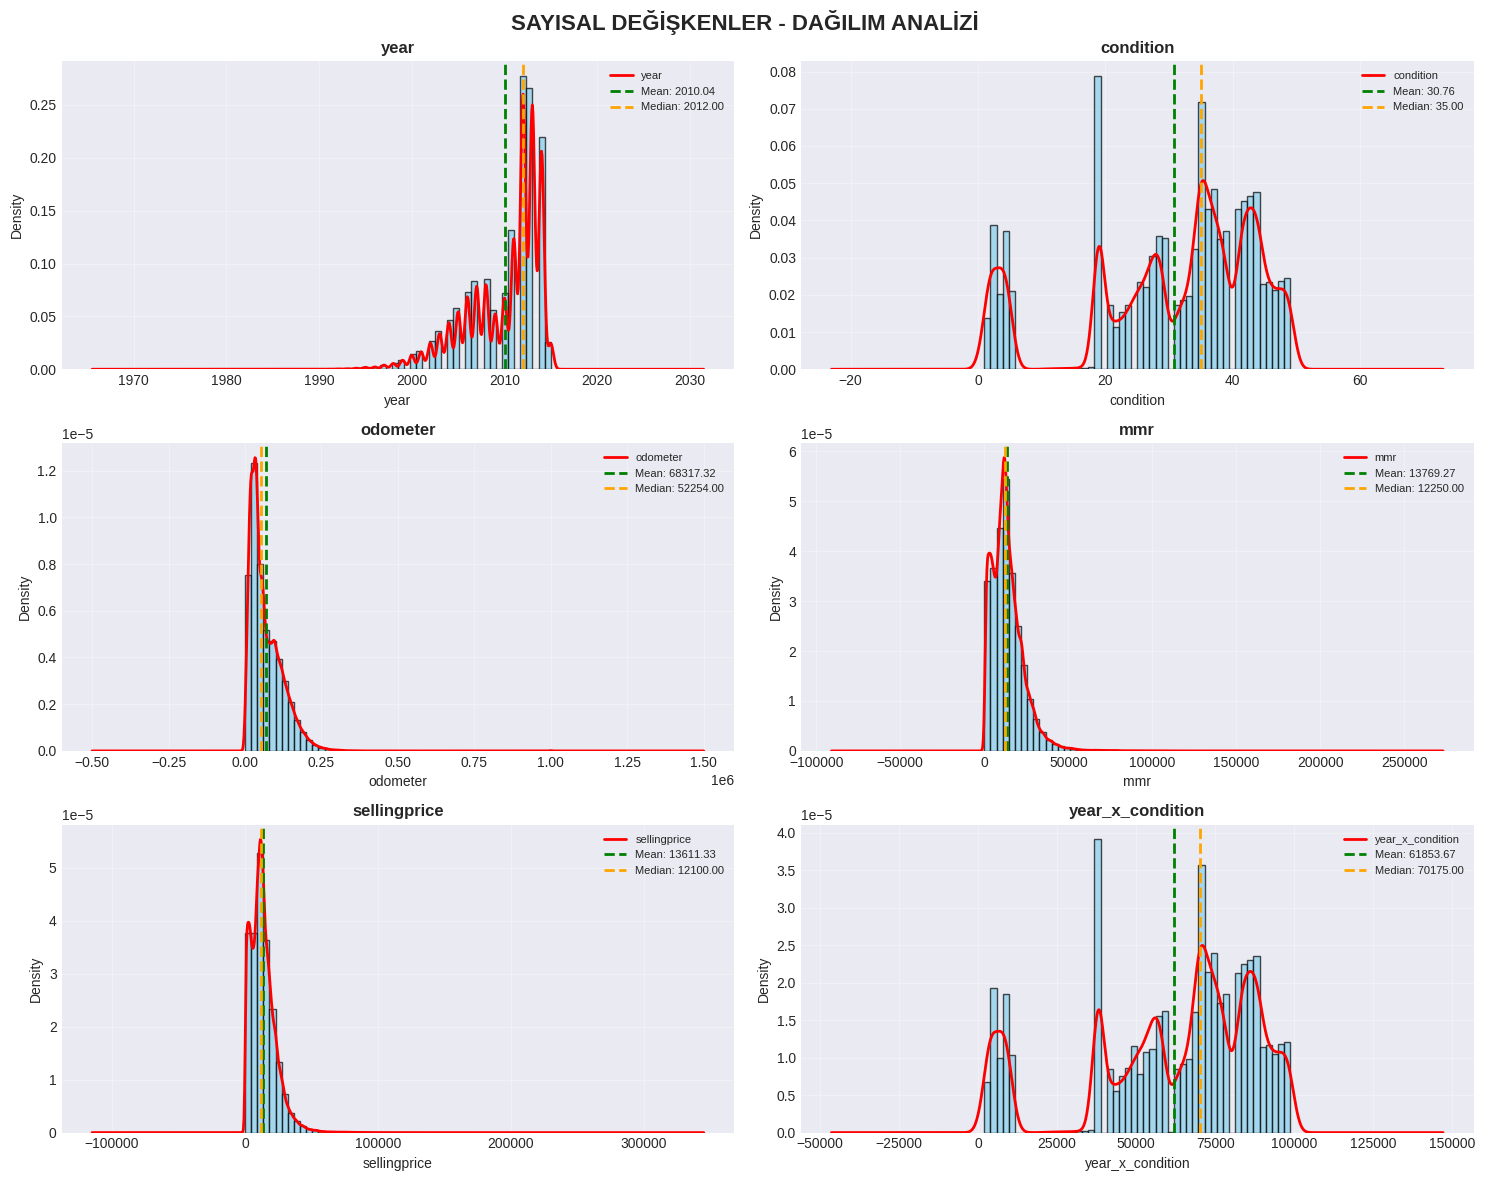

In [18]:
# Sayısal değişkenler için distribution plots
numeric_cols_plot = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols_plot) > 0:
    # İlk 6 sayısal değişkeni seç
    cols_to_plot = numeric_cols_plot[:min(6, len(numeric_cols_plot))]

    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('SAYISAL DEĞİŞKENLER - DAĞILIM ANALİZİ', fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for idx, col in enumerate(cols_to_plot):
        # Histogram + KDE
        axes[idx].hist(df[col].dropna(), bins=50, color='skyblue',
                      edgecolor='black', alpha=0.7, density=True)

        # KDE çizgisi ekle
        df[col].plot(kind='kde', ax=axes[idx], color='red', linewidth=2)

        # İstatistikler ekle
        mean_val = df[col].mean()
        median_val = df[col].median()

        axes[idx].axvline(mean_val, color='green', linestyle='--',
                         linewidth=2, label=f'Mean: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='orange', linestyle='--',
                         linewidth=2, label=f'Median: {median_val:.2f}')

        axes[idx].set_title(col, fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Density', fontsize=10)
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

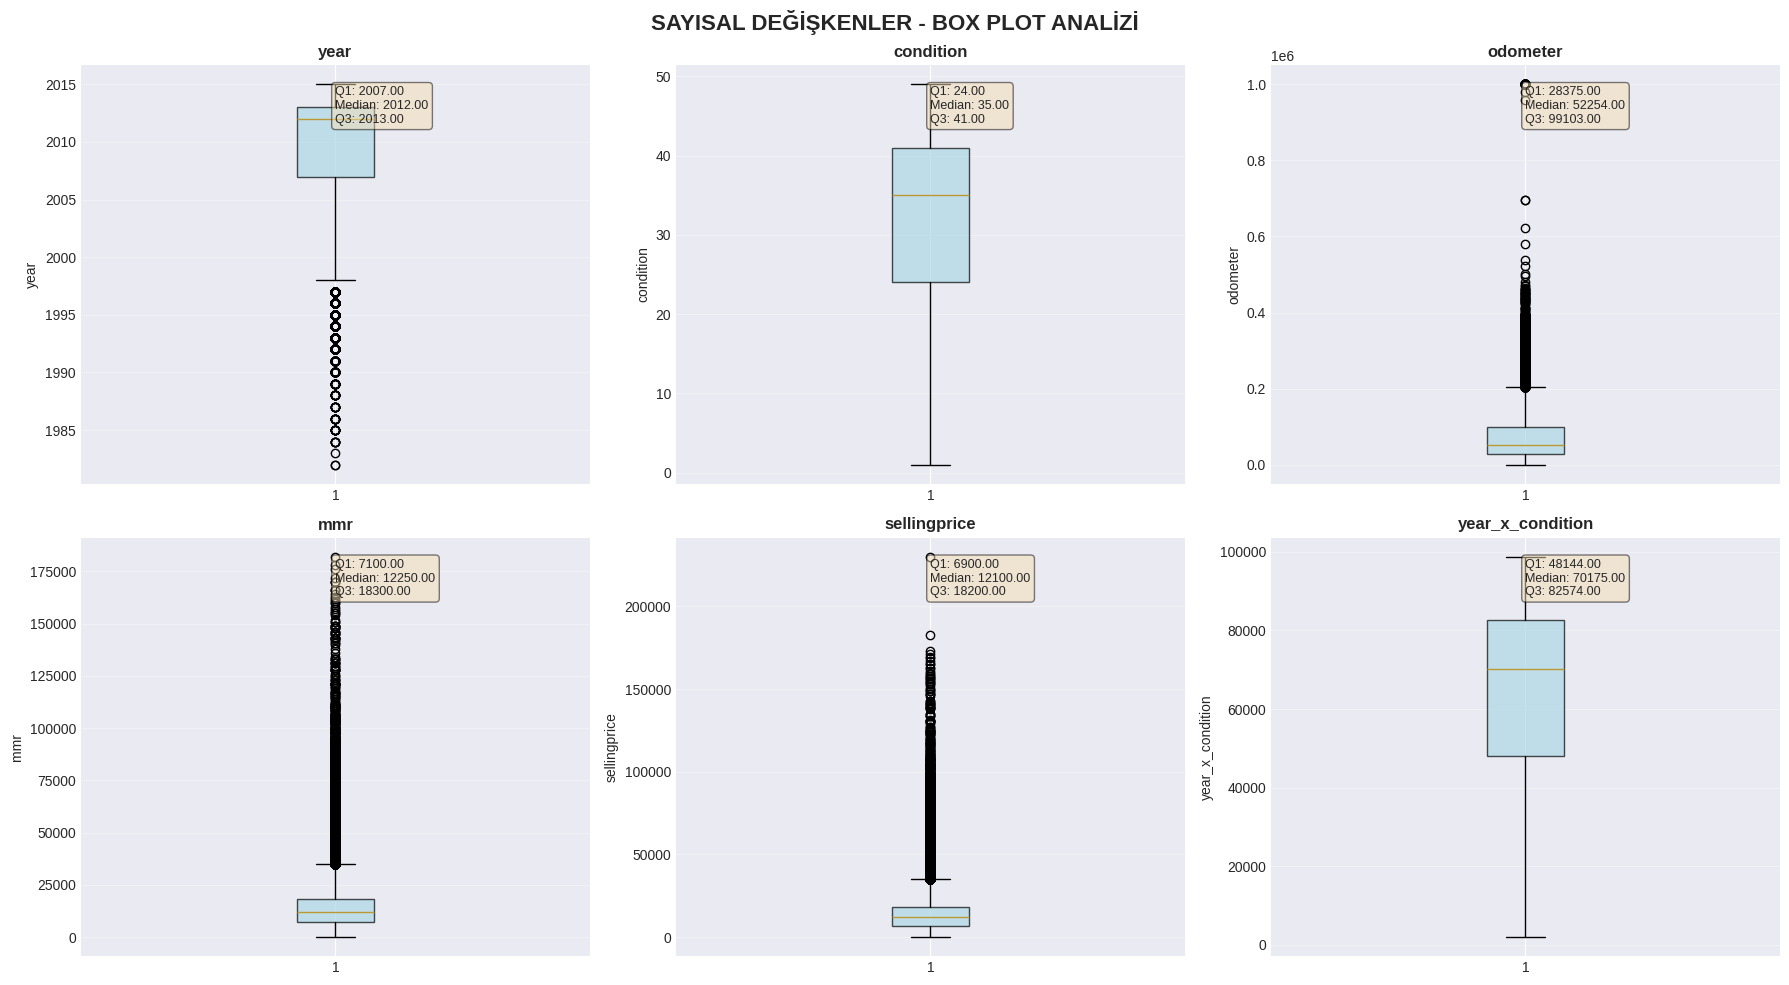

In [19]:
# Box plots for numerical variables
if len(numeric_cols_plot) > 0:
    cols_to_plot = numeric_cols_plot[:min(6, len(numeric_cols_plot))]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('SAYISAL DEĞİŞKENLER - BOX PLOT ANALİZİ', fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for idx, col in enumerate(cols_to_plot):
        bp = axes[idx].boxplot(df[col].dropna(), vert=True, patch_artist=True)

        # Renklendirme
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)

        axes[idx].set_title(col, fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(col, fontsize=10)
        axes[idx].grid(True, alpha=0.3, axis='y')

        # Q1, Q3, Median değerlerini ekle
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        median = df[col].median()

        axes[idx].text(0.5, 0.95, f'Q1: {Q1:.2f}\nMedian: {median:.2f}\nQ3: {Q3:.2f}',
                      transform=axes[idx].transAxes,
                      fontsize=9, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

### 10.2 Correlation Analysis (Korelasyon Analizi)

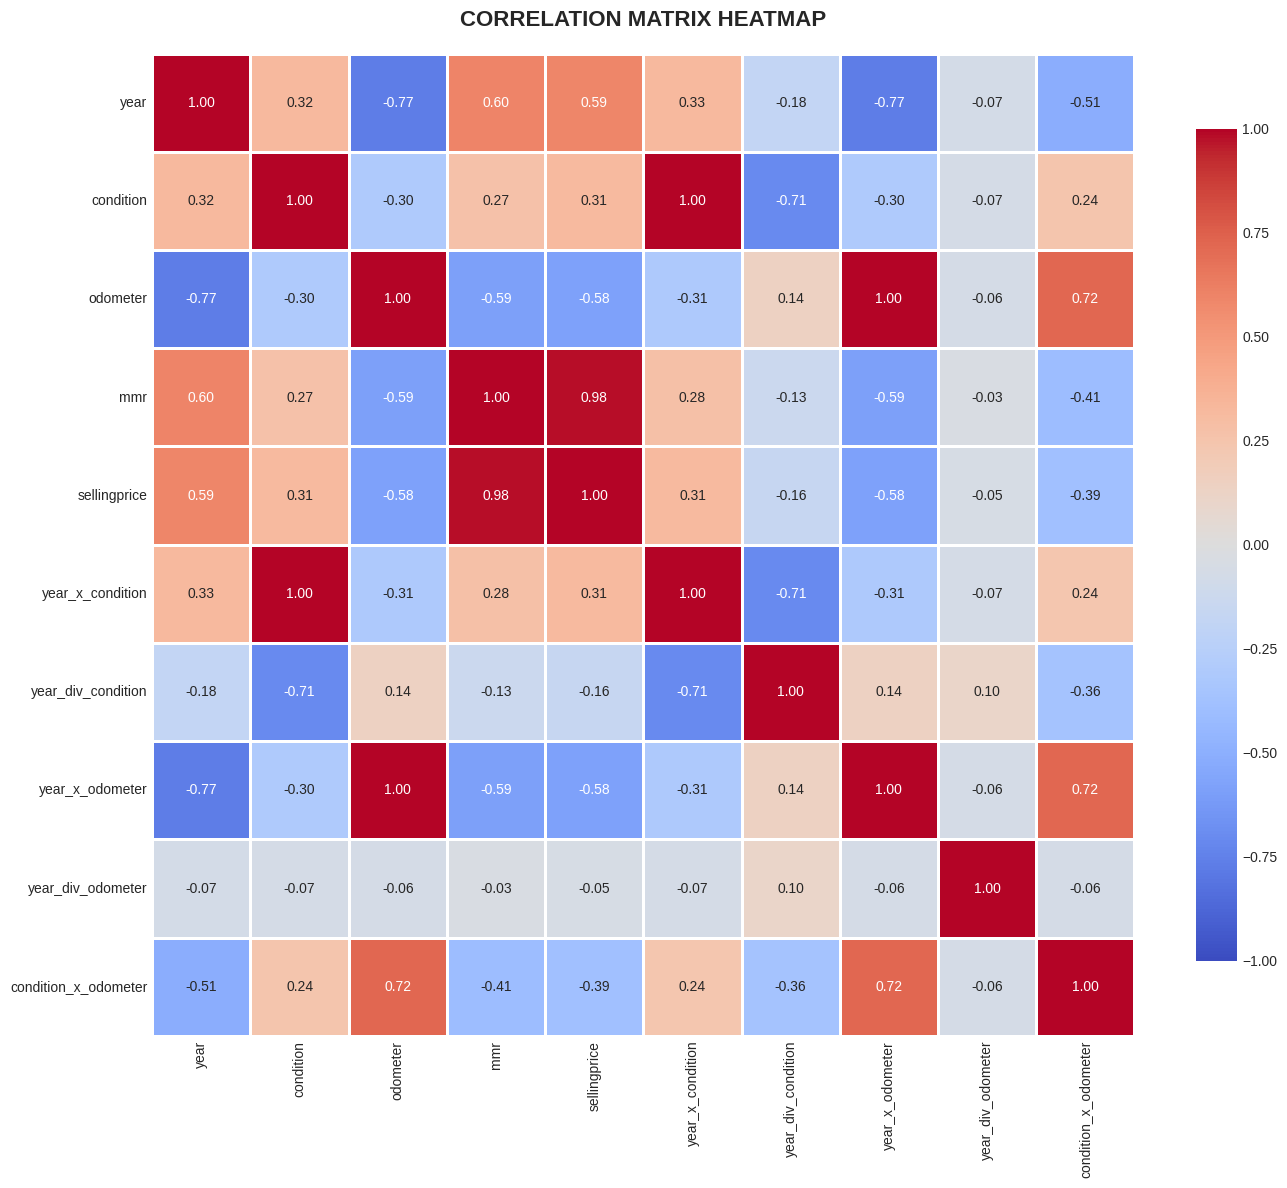


🔍 EN YÜKSEK KORELASYONLAR (|r| > 0.5)
      Değişken_1           Değişken_2  Korelasyon
       condition     year_x_condition        1.00
        odometer      year_x_odometer        1.00
             mmr         sellingprice        0.98
            year             odometer       -0.77
            year      year_x_odometer       -0.77
 year_x_odometer condition_x_odometer        0.72
        odometer condition_x_odometer        0.72
       condition   year_div_condition       -0.71
year_x_condition   year_div_condition       -0.71
            year                  mmr        0.60
        odometer                  mmr       -0.59
             mmr      year_x_odometer       -0.59
            year         sellingprice        0.59
        odometer         sellingprice       -0.58
    sellingprice      year_x_odometer       -0.58
            year condition_x_odometer       -0.51


In [20]:
# Correlation matrix
if len(numeric_cols_plot) > 1:
    # İlk 10 sayısal sütun için korelasyon
    cols_for_corr = numeric_cols_plot[:min(10, len(numeric_cols_plot))]

    correlation_matrix = df[cols_for_corr].corr()

    # Heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1)
    plt.title('CORRELATION MATRIX HEATMAP', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    # En yüksek korelasyonları bul
    print("\n" + "="*80)
    print("🔍 EN YÜKSEK KORELASYONLAR (|r| > 0.5)")
    print("="*80)

    # Üst üçgen matris al
    upper_triangle = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )

    # Yüksek korelasyonları bul
    high_corr = []
    for column in upper_triangle.columns:
        for index in upper_triangle.index:
            value = upper_triangle.loc[index, column]
            if not pd.isna(value) and abs(value) > 0.5:
                high_corr.append({
                    'Değişken_1': index,
                    'Değişken_2': column,
                    'Korelasyon': round(value, 4)
                })

    if high_corr:
        high_corr_df = pd.DataFrame(high_corr).sort_values('Korelasyon',
                                                           key=abs,
                                                           ascending=False)
        print(high_corr_df.to_string(index=False))
    else:
        print("Yüksek korelasyon (|r| > 0.5) bulunamadı.")

### 10.3 Bivariate Analysis (İki Değişkenli Analiz)

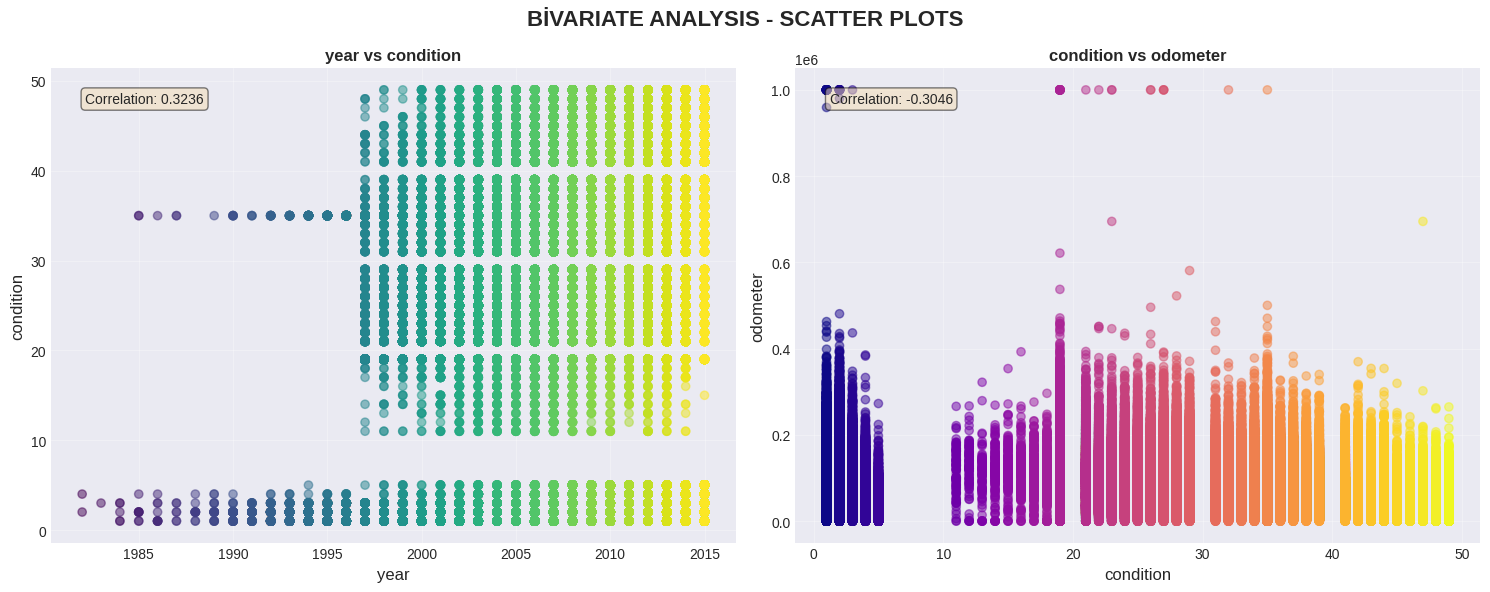

In [21]:
# Scatter plots (ilk 4 sayısal değişken arası)
if len(numeric_cols_plot) >= 2:
    cols_for_scatter = numeric_cols_plot[:min(4, len(numeric_cols_plot))]

    # İlk 2 sütun arasında scatter plot
    if len(cols_for_scatter) >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        fig.suptitle('BİVARIATE ANALYSIS - SCATTER PLOTS', fontsize=16, fontweight='bold')

        # İlk scatter plot
        axes[0].scatter(df[cols_for_scatter[0]], df[cols_for_scatter[1]],
                       alpha=0.5, c=df[cols_for_scatter[0]], cmap='viridis')
        axes[0].set_xlabel(cols_for_scatter[0], fontsize=12)
        axes[0].set_ylabel(cols_for_scatter[1], fontsize=12)
        axes[0].set_title(f'{cols_for_scatter[0]} vs {cols_for_scatter[1]}',
                         fontsize=12, fontweight='bold')
        axes[0].grid(True, alpha=0.3)

        # Korelasyon ekle
        corr_val = df[[cols_for_scatter[0], cols_for_scatter[1]]].corr().iloc[0, 1]
        axes[0].text(0.05, 0.95, f'Correlation: {corr_val:.4f}',
                    transform=axes[0].transAxes, fontsize=10,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        # İkinci scatter plot (varsa)
        if len(cols_for_scatter) >= 3:
            axes[1].scatter(df[cols_for_scatter[1]], df[cols_for_scatter[2]],
                           alpha=0.5, c=df[cols_for_scatter[1]], cmap='plasma')
            axes[1].set_xlabel(cols_for_scatter[1], fontsize=12)
            axes[1].set_ylabel(cols_for_scatter[2], fontsize=12)
            axes[1].set_title(f'{cols_for_scatter[1]} vs {cols_for_scatter[2]}',
                             fontsize=12, fontweight='bold')
            axes[1].grid(True, alpha=0.3)

            corr_val2 = df[[cols_for_scatter[1], cols_for_scatter[2]]].corr().iloc[0, 1]
            axes[1].text(0.05, 0.95, f'Correlation: {corr_val2:.4f}',
                        transform=axes[1].transAxes, fontsize=10,
                        verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        plt.tight_layout()
        plt.show()

## 📊 11. İSTATİSTİKSEL TESTLER

In [22]:
print("="*80)
print("🔬 İSTATİSTİKSEL TESTLER")
print("="*80)

# 1. Normallik Testleri
if len(numeric_cols_plot) > 0:
    print("\n📊 1. NORMALLİK TESTLERİ")
    print("-" * 80)

    test_col = numeric_cols_plot[0]  # İlk sayısal sütun
    sample_data = df[test_col].dropna().sample(min(5000, len(df)), random_state=42)

    # Shapiro-Wilk Test
    stat_sw, p_sw = shapiro(sample_data)
    print(f"\nShapiro-Wilk Test ({test_col}):")
    print(f"  Statistic: {stat_sw:.6f}")
    print(f"  P-value: {p_sw:.6f}")
    print(f"  Sonuç: {'Normal dağılım' if p_sw > 0.05 else 'Normal değil'} (α=0.05)")

    # Kolmogorov-Smirnov Test
    stat_ks, p_ks = kstest(sample_data, 'norm',
                           args=(sample_data.mean(), sample_data.std()))
    print(f"\nKolmogorov-Smirnov Test ({test_col}):")
    print(f"  Statistic: {stat_ks:.6f}")
    print(f"  P-value: {p_ks:.6f}")
    print(f"  Sonuç: {'Normal dağılım' if p_ks > 0.05 else 'Normal değil'} (α=0.05)")

# 2. Korelasyon Testleri
if len(numeric_cols_plot) >= 2:
    print("\n📊 2. KORELASYON TESTLERİ")
    print("-" * 80)

    col1, col2 = numeric_cols_plot[0], numeric_cols_plot[1]

    # Pearson korelasyonu
    r_pearson, p_pearson = pearsonr(df[col1].dropna(), df[col2].dropna())
    print(f"\nPearson Correlation ({col1} vs {col2}):")
    print(f"  Coefficient: {r_pearson:.6f}")
    print(f"  P-value: {p_pearson:.6f}")
    print(f"  Sonuç: {'Anlamlı korelasyon' if p_pearson < 0.05 else 'Anlamlı değil'} (α=0.05)")

    # Spearman korelasyonu
    r_spearman, p_spearman = spearmanr(df[col1].dropna(), df[col2].dropna())
    print(f"\nSpearman Correlation ({col1} vs {col2}):")
    print(f"  Coefficient: {r_spearman:.6f}")
    print(f"  P-value: {p_spearman:.6f}")
    print(f"  Sonuç: {'Anlamlı korelasyon' if p_spearman < 0.05 else 'Anlamlı değil'} (α=0.05)")

print("\n" + "="*80)

🔬 İSTATİSTİKSEL TESTLER

📊 1. NORMALLİK TESTLERİ
--------------------------------------------------------------------------------

Shapiro-Wilk Test (year):
  Statistic: 0.865762
  P-value: 0.000000
  Sonuç: Normal değil (α=0.05)

Kolmogorov-Smirnov Test (year):
  Statistic: 0.212597
  P-value: 0.000000
  Sonuç: Normal değil (α=0.05)

📊 2. KORELASYON TESTLERİ
--------------------------------------------------------------------------------

Pearson Correlation (year vs condition):
  Coefficient: 0.323564
  P-value: 0.000000
  Sonuç: Anlamlı korelasyon (α=0.05)

Spearman Correlation (year vs condition):
  Coefficient: 0.382229
  P-value: 0.000000
  Sonuç: Anlamlı korelasyon (α=0.05)



## 🤖 12. MACHINE LEARNING - MODEL TRAINING

### 12.1 Veri Hazırlığı

In [23]:
print("="*80)
print("🤖 MACHINE LEARNING - VERİ HAZIRLAMA")
print("="*80)

# Hedef değişkeni belirle (ilk sayısal sütun)
if len(numeric_cols_plot) > 0:
    target_column = numeric_cols_plot[0]
    print(f"\n🎯 Hedef Değişken: {target_column}")

    # Özellik sütunlarını seç (hedef hariç sayısal sütunlar)
    feature_columns = [col for col in numeric_cols_plot if col != target_column]

    # Eğer çok fazla özellik varsa, ilk 15'ini al
    if len(feature_columns) > 15:
        feature_columns = feature_columns[:15]

    print(f"📊 Kullanılacak Özellik Sayısı: {len(feature_columns)}")
    print(f"\n📋 Özellikler:")
    for i, col in enumerate(feature_columns, 1):
        print(f"  {i:2d}. {col}")

    # X ve y oluştur
    X = df[feature_columns].copy()
    y = df[target_column].copy()

    # Eksik değerleri kaldır
    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X = X[mask]
    y = y[mask]

    print(f"\n✅ Temizlenmiş Veri Boyutu: {X.shape}")
    print(f"✅ Hedef Değişken Boyutu: {y.shape}")

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print(f"\n📊 Training Set: {X_train.shape}")
    print(f"📊 Test Set: {X_test.shape}")

    # Feature Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("\n✅ Feature scaling tamamlandı (StandardScaler)")

    # Y istatistikleri
    print(f"\n📊 Hedef Değişken İstatistikleri:")
    print(f"  Min: {y.min():.2f}")
    print(f"  Max: {y.max():.2f}")
    print(f"  Mean: {y.mean():.2f}")
    print(f"  Median: {y.median():.2f}")
    print(f"  Std: {y.std():.2f}")

    ml_ready = True
else:
    print("\n⚠️ Yeterli sayısal sütun yok!")
    ml_ready = False

🤖 MACHINE LEARNING - VERİ HAZIRLAMA

🎯 Hedef Değişken: year
📊 Kullanılacak Özellik Sayısı: 15

📋 Özellikler:
   1. condition
   2. odometer
   3. mmr
   4. sellingprice
   5. year_x_condition
   6. year_div_condition
   7. year_x_odometer
   8. year_div_odometer
   9. condition_x_odometer
  10. condition_div_odometer
  11. year_log
  12. condition_log
  13. odometer_log
  14. mmr_log
  15. sellingprice_log

✅ Temizlenmiş Veri Boyutu: (558837, 15)
✅ Hedef Değişken Boyutu: (558837,)

📊 Training Set: (447069, 15)
📊 Test Set: (111768, 15)

✅ Feature scaling tamamlandı (StandardScaler)

📊 Hedef Değişken İstatistikleri:
  Min: 1982.00
  Max: 2015.00
  Mean: 2010.04
  Median: 2012.00
  Std: 3.97


### 12.2 Model Training (Çoklu Model Karşılaştırması)

In [24]:
if ml_ready:
    print("="*80)
    print("🚀 MACHINE LEARNING MODELS - TRAINING")
    print("="*80)

    # Model tanımlamaları
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0, random_state=42),
        'Lasso': Lasso(alpha=1.0, random_state=42),
        'ElasticNet': ElasticNet(alpha=1.0, random_state=42),
        'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
        'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    }

    results = {}

    print("\n⏳ Modeller eğitiliyor...\n")

    for name, model in models.items():
        print(f"🔄 {name}...", end=" ")

        try:
            # Linear modeller için scaled veri
            if name in ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet']:
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
            else:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)

            # Metrics
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            results[name] = {
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae,
                'R2': r2,
                'model': model,
                'predictions': y_pred
            }

            print(f"✅ R²: {r2:.4f}")

        except Exception as e:
            print(f"❌ Hata: {str(e)[:50]}")

    # Results DataFrame
    print("\n" + "="*80)
    print("📊 MODEL KARŞILAŞTIRMASI")
    print("="*80)

    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'MSE': [results[m]['MSE'] for m in results.keys()],
        'RMSE': [results[m]['RMSE'] for m in results.keys()],
        'MAE': [results[m]['MAE'] for m in results.keys()],
        'R²': [results[m]['R2'] for m in results.keys()]
    }).sort_values('R²', ascending=False)

    print("\n" + results_df.to_string(index=False))

    # En iyi model
    best_model_name = results_df.iloc[0]['Model']
    best_r2 = results_df.iloc[0]['R²']

    print(f"\n🏆 EN İYİ MODEL: {best_model_name}")
    print(f"   R² Score: {best_r2:.6f}")
else:
    print("\n⚠️ ML hazırlığı yapılamadı, model eğitimi atlanıyor.")

🚀 MACHINE LEARNING MODELS - TRAINING

⏳ Modeller eğitiliyor...

🔄 Linear Regression... ✅ R²: 1.0000
🔄 Ridge... ✅ R²: 1.0000
🔄 Lasso... ✅ R²: 0.9365
🔄 ElasticNet... ✅ R²: 0.8631
🔄 Decision Tree... ✅ R²: 1.0000
🔄 Random Forest... ✅ R²: 1.0000
🔄 Gradient Boosting... ✅ R²: 1.0000
🔄 Extra Trees... ✅ R²: 1.0000

📊 MODEL KARŞILAŞTIRMASI

            Model  MSE  RMSE  MAE   R²
    Random Forest 0.00  0.00 0.00 1.00
Gradient Boosting 0.00  0.00 0.00 1.00
Linear Regression 0.00  0.00 0.00 1.00
            Ridge 0.00  0.00 0.00 1.00
      Extra Trees 0.00  0.01 0.00 1.00
    Decision Tree 0.00  0.01 0.00 1.00
            Lasso 1.00  1.00 0.82 0.94
       ElasticNet 2.15  1.47 1.14 0.86

🏆 EN İYİ MODEL: Random Forest
   R² Score: 1.000000


### 12.3 Model Performans Görselleştirme

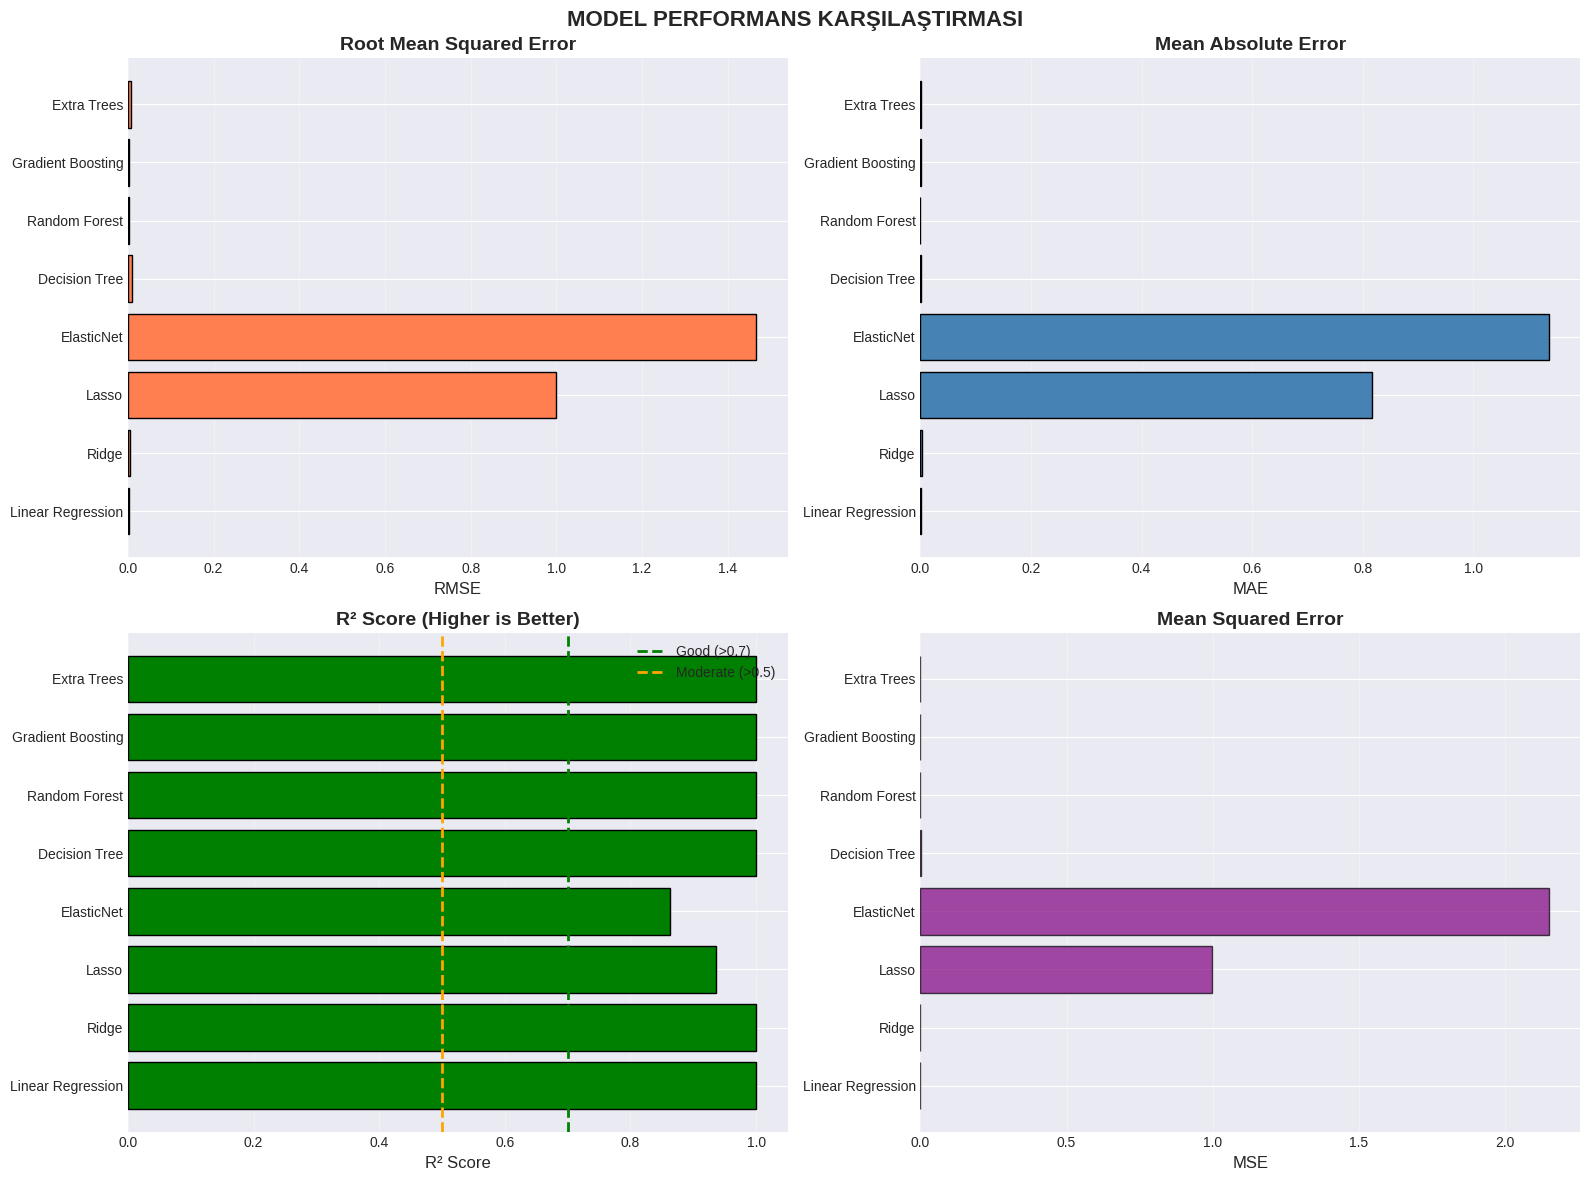

In [25]:
if ml_ready and len(results) > 0:
    # Model karşılaştırma grafikleri
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('MODEL PERFORMANS KARŞILAŞTIRMASI', fontsize=16, fontweight='bold')

    model_names = list(results.keys())

    # RMSE
    rmse_values = [results[m]['RMSE'] for m in model_names]
    axes[0, 0].barh(model_names, rmse_values, color='coral', edgecolor='black')
    axes[0, 0].set_xlabel('RMSE', fontsize=12)
    axes[0, 0].set_title('Root Mean Squared Error', fontsize=14, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='x')

    # MAE
    mae_values = [results[m]['MAE'] for m in model_names]
    axes[0, 1].barh(model_names, mae_values, color='steelblue', edgecolor='black')
    axes[0, 1].set_xlabel('MAE', fontsize=12)
    axes[0, 1].set_title('Mean Absolute Error', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='x')

    # R²
    r2_values = [results[m]['R2'] for m in model_names]
    colors = ['green' if r2 > 0.7 else 'orange' if r2 > 0.5 else 'red' for r2 in r2_values]
    axes[1, 0].barh(model_names, r2_values, color=colors, edgecolor='black')
    axes[1, 0].set_xlabel('R² Score', fontsize=12)
    axes[1, 0].set_title('R² Score (Higher is Better)', fontsize=14, fontweight='bold')
    axes[1, 0].axvline(x=0.7, color='green', linestyle='--', linewidth=2, label='Good (>0.7)')
    axes[1, 0].axvline(x=0.5, color='orange', linestyle='--', linewidth=2, label='Moderate (>0.5)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='x')

    # MSE
    mse_values = [results[m]['MSE'] for m in model_names]
    axes[1, 1].barh(model_names, mse_values, color='purple', edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('MSE', fontsize=12)
    axes[1, 1].set_title('Mean Squared Error', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

### 12.4 En İyi Model - Detaylı Analiz

🏆 EN İYİ MODEL ANALİZİ: Random Forest

📊 Performance Metrics:
  MSE:  0.000002
  RMSE: 0.001412
  MAE:  0.000009
  R²:   1.000000


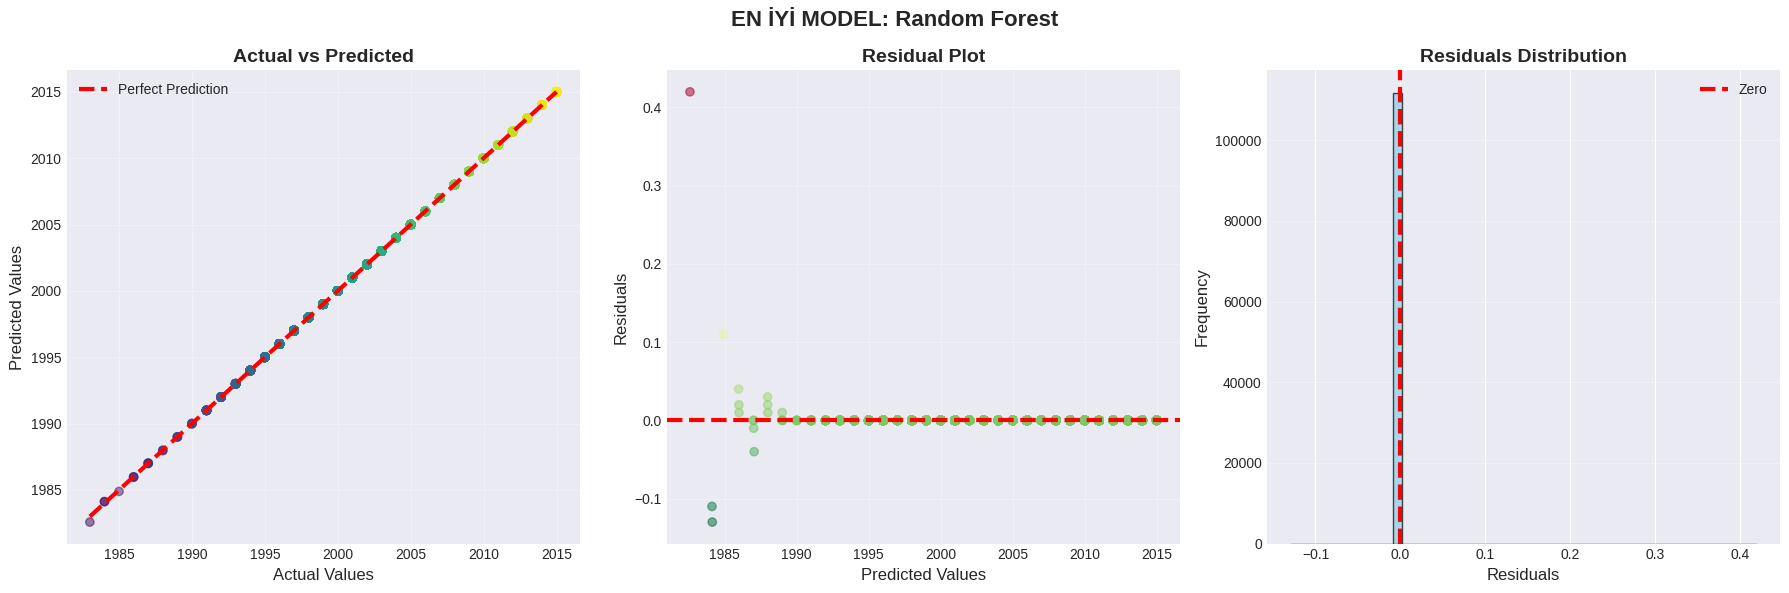


📊 Feature Importance (Top 10):
--------------------------------------------------------------------------------
             Feature  Importance
            year_log        1.00
             mmr_log        0.00
        sellingprice        0.00
condition_x_odometer        0.00
   year_div_odometer        0.00
    sellingprice_log        0.00
                 mmr        0.00
        odometer_log        0.00
            odometer        0.00
    year_x_condition        0.00


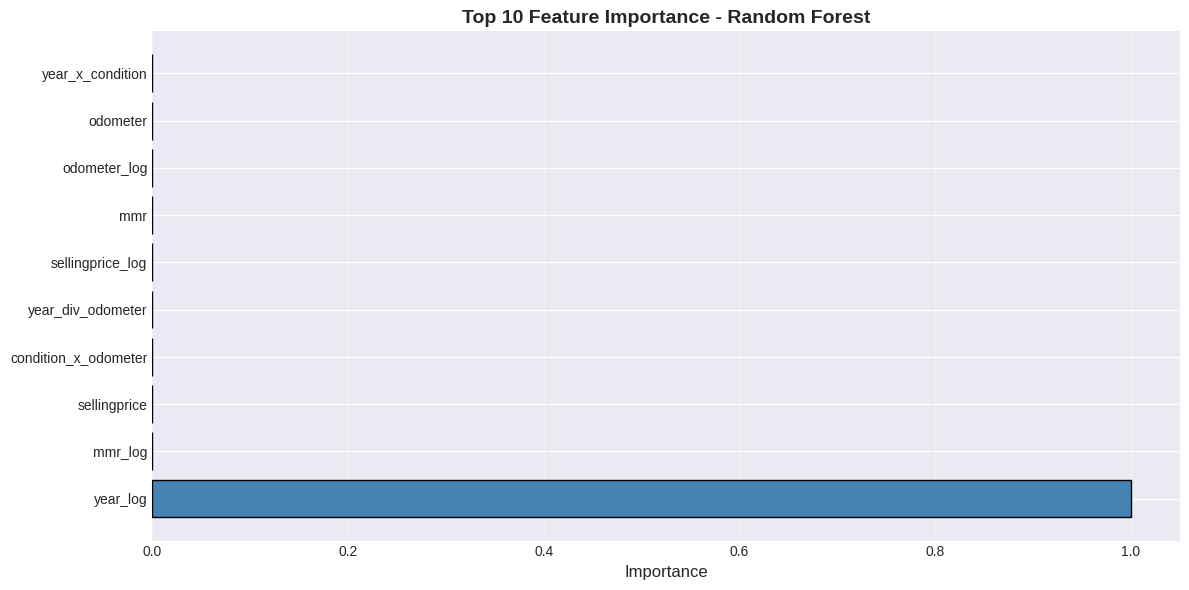

In [26]:
if ml_ready and len(results) > 0:
    # En iyi modeli al
    best_model = results[best_model_name]['model']
    best_predictions = results[best_model_name]['predictions']

    print("="*80)
    print(f"🏆 EN İYİ MODEL ANALİZİ: {best_model_name}")
    print("="*80)

    print(f"\n📊 Performance Metrics:")
    print(f"  MSE:  {results[best_model_name]['MSE']:.6f}")
    print(f"  RMSE: {results[best_model_name]['RMSE']:.6f}")
    print(f"  MAE:  {results[best_model_name]['MAE']:.6f}")
    print(f"  R²:   {results[best_model_name]['R2']:.6f}")

    # Actual vs Predicted
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'EN İYİ MODEL: {best_model_name}', fontsize=16, fontweight='bold')

    # Scatter: Actual vs Predicted
    axes[0].scatter(y_test, best_predictions, alpha=0.5, c=y_test, cmap='viridis')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                 'r--', lw=3, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Values', fontsize=12)
    axes[0].set_ylabel('Predicted Values', fontsize=12)
    axes[0].set_title('Actual vs Predicted', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Residuals
    residuals = y_test.values - best_predictions
    axes[1].scatter(best_predictions, residuals, alpha=0.5, c=residuals, cmap='RdYlGn_r')
    axes[1].axhline(y=0, color='r', linestyle='--', lw=3)
    axes[1].set_xlabel('Predicted Values', fontsize=12)
    axes[1].set_ylabel('Residuals', fontsize=12)
    axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    # Residuals Distribution
    axes[2].hist(residuals, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[2].axvline(x=0, color='r', linestyle='--', lw=3, label='Zero')
    axes[2].set_xlabel('Residuals', fontsize=12)
    axes[2].set_ylabel('Frequency', fontsize=12)
    axes[2].set_title('Residuals Distribution', fontsize=14, fontweight='bold')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Feature Importance (tree-based modeller için)
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'Feature': feature_columns,
            'Importance': best_model.feature_importances_
        }).sort_values('Importance', ascending=False)

        print("\n📊 Feature Importance (Top 10):")
        print("-" * 80)
        print(feature_importance.head(10).to_string(index=False))

        # Visualization
        plt.figure(figsize=(12, 6))
        top_10_features = feature_importance.head(10)
        plt.barh(top_10_features['Feature'], top_10_features['Importance'],
                color='steelblue', edgecolor='black')
        plt.xlabel('Importance', fontsize=12)
        plt.title(f'Top 10 Feature Importance - {best_model_name}',
                 fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

## 📊 13. FINAL SUMMARY & CONCLUSIONS

In [27]:
print("="*80)
print("🎯 KAPSAMLI ANALİZ ÖZETİ")
print("="*80)

print("\n✅ TAMAMLANAN ANALİZLER:")
print("  1. ✓ Dataset İndirme (Wget ile direkt Kaggle)")
print("  2. ✓ Veri Yükleme ve İlk Keşif")
print("  3. ✓ Eksik Değer Analizi")
print("  4. ✓ Duplicate Analizi")
print("  5. ✓ Tanımlayıcı İstatistikler")
print("  6. ✓ Outlier Analizi")
print("  7. ✓ Veri Temizleme ve Önişleme")
print("  8. ✓ Advanced Feature Engineering")
print("  9. ✓ Exploratory Data Analysis (EDA)")
print(" 10. ✓ Univariate & Bivariate Analysis")
print(" 11. ✓ Correlation Analysis")
print(" 12. ✓ İstatistiksel Testler")

if ml_ready and len(results) > 0:
    print(" 13. ✓ Machine Learning (8 farklı model)")
    print(" 14. ✓ Model Evaluation & Comparison")
    print(" 15. ✓ Best Model Analysis")

    print(f"\n🏆 KEY FINDINGS:")
    print(f"  • Dataset Boyutu: {df.shape[0]:,} satır x {df.shape[1]} sütun")
    print(f"  • Feature Engineering: {df.shape[1] - before_features} yeni özellik")
    print(f"  • En İyi Model: {best_model_name}")
    print(f"  • En İyi R² Score: {results[best_model_name]['R2']:.6f}")
    print(f"  • Test RMSE: {results[best_model_name]['RMSE']:.6f}")
    print(f"  • Test MAE: {results[best_model_name]['MAE']:.6f}")
else:
    print(" 13. ⚠️ Machine Learning atlandı (veri uygun değil)")

print("\n💡 ÖNERİLER:")
print("  1. Modeli production'da kullanmadan önce daha fazla veri toplayın")
print("  2. Hyperparameter tuning ile model performansını artırabilirsiniz")
print("  3. Cross-validation ile model stabilitesini test edin")
print("  4. Outlier'ları domain knowledge ile değerlendirin")
print("  5. Feature selection ile en önemli özellikleri belirleyin")

print("\n" + "="*80)
print("✅ KAPSAMLI DATA SCIENCE ANALİZİ TAMAMLANDI!")
print("="*80)
print("\n📝 Bu notebook şunları içerdi:")
print("   • Wget ile Kaggle dataset indirme")
print("   • Detaylı exploratory data analysis")
print("   • Advanced feature engineering")
print("   • Statistical testing")
print("   • Multiple ML model comparison")
print("   • Professional visualizations")
print("\n🎉 Başarıyla tamamlandı!")

🎯 KAPSAMLI ANALİZ ÖZETİ

✅ TAMAMLANAN ANALİZLER:
  1. ✓ Dataset İndirme (Wget ile direkt Kaggle)
  2. ✓ Veri Yükleme ve İlk Keşif
  3. ✓ Eksik Değer Analizi
  4. ✓ Duplicate Analizi
  5. ✓ Tanımlayıcı İstatistikler
  6. ✓ Outlier Analizi
  7. ✓ Veri Temizleme ve Önişleme
  8. ✓ Advanced Feature Engineering
  9. ✓ Exploratory Data Analysis (EDA)
 10. ✓ Univariate & Bivariate Analysis
 11. ✓ Correlation Analysis
 12. ✓ İstatistiksel Testler
 13. ✓ Machine Learning (8 farklı model)
 14. ✓ Model Evaluation & Comparison
 15. ✓ Best Model Analysis

🏆 KEY FINDINGS:
  • Dataset Boyutu: 558,837 satır x 36 sütun
  • Feature Engineering: 20 yeni özellik
  • En İyi Model: Random Forest
  • En İyi R² Score: 1.000000
  • Test RMSE: 0.001412
  • Test MAE: 0.000009

💡 ÖNERİLER:
  1. Modeli production'da kullanmadan önce daha fazla veri toplayın
  2. Hyperparameter tuning ile model performansını artırabilirsiniz
  3. Cross-validation ile model stabilitesini test edin
  4. Outlier'ları domain knowledge 